# AutoGrasp V2 — collect any object, shape-adaptive grasping

**What's V2 here** (the rest is the proven collection engine):
1. **Shape-gated ladder** drives the grasp angle by object shape — box→minAreaRect,
   apple/lemon→polygon, banana→skeleton. (V1 forced minAreaRect on everything.)
2. **Auto-detect** — `ACTIVE_OVERRIDE=''` in `mem_manager`, so any object placed is named
   by Gemini, segmented by SAM3, and grasped. No per-object edits.

Run cells top to bottom. The grasp cell prints `[ladder] ...` every grasp; on a box the
ladder agrees with minAreaRect (dev ~0°) — the control proof. Toggle `LADDER_DRIVES_ANGLE`
in `mem_manager`.


In [1]:
import subprocess, os, time

SAM3_PY  = os.path.expanduser('~/sam3_env/bin/python3')
SAM3_SCR = os.path.expanduser('~/magpie_control/scripts/sam3_infer.py')
ROS      = 'source /opt/ros/humble/setup.bash && source ~/ws_ctrl/install/setup.bash'

def ros_proc(cmd, log):
    open(log, 'w').close()
    return subprocess.Popen(f'{ROS} && {cmd}', shell=True, executable='/bin/bash',
                            stdout=open(log, 'a'), stderr=subprocess.STDOUT)

print('Killing stale processes...')
_procs = ['ur5_node', 'gripper_node', 'realsense2_camera', 'sam3_infer', 'slip_guard_node', 'ft_sensor_node', 'graspgenx_server']
for p in _procs:
    subprocess.run(f'pkill -f {p}', shell=True)      # SIGTERM: ur5_node catches it and releases its RTDE script cleanly
time.sleep(2.5)                                       # let nodes shut down gracefully
for p in _procs:
    subprocess.run(f'pkill -9 -f {p}', shell=True)    # force-kill any stragglers that ignored SIGTERM
subprocess.run('rm -f /tmp/sam3.sock', shell=True)
time.sleep(3)

PROCS = {}
PROCS['ur5']     = ros_proc('ros2 run magpie_control ur5_node',     '/tmp/log_ur5.txt')
PROCS['gripper'] = ros_proc('ros2 run magpie_control gripper_node', '/tmp/log_gripper.txt')
PROCS['ft']      = ros_proc('ros2 run magpie_control ft_sensor_node', '/tmp/log_ft.txt')
PROCS['camera']  = ros_proc(
    'ros2 run realsense2_camera realsense2_camera_node --ros-args -r __ns:=/camera/gripper_camera',
    '/tmp/log_camera.txt')
PROCS['slip_guard'] = ros_proc(
    f'python3 {os.path.expanduser("~/magpie_control/scripts/slip_guard_node.py")}',
    '/tmp/log_slip_guard.txt')
PROCS['sam3']    = subprocess.Popen(
    [SAM3_PY, SAM3_SCR, '--socket'],
    stdout=open('/tmp/log_sam3.txt', 'w'), stderr=subprocess.STDOUT)

# ── Grasp memory (force priors + DINO RAG) ──────────────────────────
import sys as _sys
_sys.path.insert(0, os.path.expanduser('~/magpie_control/scripts'))
from grasp_memory import GraspMemory
gm = GraspMemory(os.path.expanduser('~/magpie_control/data/grasp_log'))
print(f'GraspMemory loaded — {len(gm._priors)} known objects')

print('Waiting for SAM3 (up to 90s)...')
for i in range(90):
    time.sleep(1)
    if os.path.exists('/tmp/sam3.sock'):
        print(f'  SAM3 ready after {i+1}s')
        break
    if PROCS['sam3'].poll() is not None:
        print('  SAM3 crashed:'); print(open('/tmp/log_sam3.txt').read()[-600:])
        break
    if (i+1) % 20 == 0:
        print(f'  {i+1}s...')

time.sleep(3)
print()
# Auto-retry ur5 if it didn't come up — the dashboard-clear in ur5.start() means a retry
# almost always succeeds WITHOUT a pendant controller restart.
for _try in range(2):
    if PROCS['ur5'].poll() is None: break
    print(f'  ur5 EXITED — auto-retrying ({_try+1}/2, self-clearing stuck script)...')
    subprocess.run('pkill -9 -f ur5_node', shell=True); time.sleep(2)
    PROCS['ur5'] = ros_proc('ros2 run magpie_control ur5_node', '/tmp/log_ur5.txt')
    time.sleep(6)

# ── Preload GraspGenX server in background ────────────────────────────────────
# GraspGenX (~0.8 GB) coexists with SAM3 (~3.9 GB) on the 8 GB card — measured
# ~3 GB headroom. Start the ZMQ server now (loads in ~10s) so it's warm for the
# first grasp and stays warm all session (no per-grasp swap).
_ggx_sh = os.path.expanduser('~/magpie_control/scripts/run_graspgenx_server.sh')
if os.path.exists(_ggx_sh):
    PROCS['graspgenx'] = subprocess.Popen(
        ['bash', _ggx_sh],
        stdout=open('/tmp/log_graspgenx.txt', 'w'), stderr=subprocess.STDOUT)
    print('  graspgenx  STARTING (loading model in background, ~60s — see /tmp/log_graspgenx.txt)')
else:
    print('  graspgenx  script not found — will auto-start if GRASP_METHOD=graspgenx')
for n, p in PROCS.items():

    status = 'OK' if p.poll() is None else f'EXITED  -> tail /tmp/log_{n}.txt'
    print(f'  {n:<10} {status}')

Killing stale processes...


/home/user/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/user/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/user/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


[GraspMemory] DINOv2 ViT-S loaded (CPU)
GraspMemory loaded — 51 known objects
Waiting for SAM3 (up to 90s)...
  SAM3 ready after 13s

  graspgenx  STARTING (loading model in background, ~60s — see /tmp/log_graspgenx.txt)
  ur5        OK
  gripper    OK
  ft         EXITED  -> tail /tmp/log_ft.txt
  camera     OK
  slip_guard OK
  sam3       OK
  graspgenx  OK


In [2]:
# ── Memory Manager ────────────────────────────────────────────────────────────
# Run this to inspect, rename, or delete entries from grasp memory.
#
# Override auto-detection for next pickup:
#   ACTIVE_OVERRIDE = 'measuring tape'
# Clear it after:
#   ACTIVE_OVERRIDE = ''

ACTIVE_OVERRIDE = ''            # ← V2: EMPTY = auto-detect any object via Gemini (put anything down).
                                #        Set a name ('red apple') only if you want consistent memory priors.
LADDER_DRIVES_ANGLE = True      # ← V2: ladder drives the angle on non-box shapes (boxes stay on minAreaRect)

print('=== Grasp Memory Contents ===')
if 'gm' not in dir():
    import sys; sys.path.insert(0, os.path.expanduser('~/magpie_control/scripts'))
    from grasp_memory import GraspMemory
    gm = GraspMemory(os.path.expanduser('~/magpie_control/data/grasp_log'))
for _name, _p in sorted(gm._priors.items(), key=lambda x: -x[1]['n']):
    print(f'  {_name:<30} n={_p["n"]:>3}  force={_p["x"]:.1f}N  std={_p["P"]**0.5:.2f}N')
print(f'\nTotal: {len(gm._priors)} objects')

# ── To delete a wrong entry ────────────────────────────────────────────────
# del gm._priors['wrong name']; gm._save_priors(); print('Deleted.')

# ── To rename a wrong entry ───────────────────────────────────────────────
# gm._priors['correct name'] = gm._priors.pop('wrong name')
# gm._save_priors(); print('Renamed.')

# ── To reset a single object to re-learn from scratch ─────────────────────
# del gm._priors['measuring tape']; gm._save_priors(); print('Reset.')


=== Grasp Memory Contents ===
  red block                      n=188  force=16.0N  std=0.50N
  red cube                       n=  3  force=1.2N  std=0.54N
  master chef can                n=  1  force=5.1N  std=1.73N
  cracker box                    n=  1  force=5.5N  std=1.73N
  sugar box                      n=  1  force=6.9N  std=1.73N
  tomato soup can                n=  1  force=4.3N  std=1.73N
  mustard bottle                 n=  1  force=8.1N  std=1.73N
  tuna fish can                  n=  1  force=2.1N  std=1.73N
  pudding box                    n=  1  force=2.8N  std=1.73N
  gelatin box                    n=  1  force=1.7N  std=1.73N
  potted meat can                n=  1  force=4.5N  std=1.73N
  banana                         n=  1  force=1.9N  std=1.73N
  pitcher base                   n=  1  force=1.1N  std=1.73N
  bleach cleanser                n=  1  force=14.5N  std=1.73N
  bowl                           n=  1  force=2.7N  std=1.73N
  mug                            n=  1

In [3]:
# ═══ GRASP-METHOD COMPARISON (uses the REAL pickup) ═══════════════════════════
# Run this once. Then per method:  set GRASP_METHOD, run the pickup cell (full run),
# reset the object to the same spot, repeat. Finally run cmp_table.
CMP_RESULTS = []
GRASP_METHOD = 'graspgenx'  # 'pca' | 'graspgen' | 'graspgenx'   (graspgenx = MAGPIE gripper, NVlabs GraspGenX)
VLA_RERUN    = 'spawn'      # opens live Rerun window — set None to disable
if 'vla_rec' in dir(): del vla_rec  # force recreation with new VLA_RERUN setting
print(f'comparison armed — GRASP_METHOD={GRASP_METHOD!r}, CMP_RESULTS reset. '
      'Set GRASP_METHOD then run the pickup.')

comparison armed — GRASP_METHOD='graspgenx', CMP_RESULTS reset. Set GRASP_METHOD then run the pickup.


In [4]:
# Load ROS shared libraries so rclpy imports in any VS Code kernel
import sys, os, ctypes, glob

for _d in [
    '/opt/ros/humble/lib/x86_64-linux-gnu',
    '/opt/ros/humble/lib',
    '/home/user/ws_ctrl/install/magpie_msgs/lib',
    '/home/user/ws_ctrl/install/magpie_control/lib',
]:
    for _so in sorted(glob.glob(_d + '/*.so*')):
        try:
            ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
        except Exception:
            pass

for _p in [
    '/opt/ros/humble/local/lib/python3.10/dist-packages',
    '/opt/ros/humble/lib/python3.10/site-packages',
    '/home/user/ws_ctrl/install/magpie_msgs/local/lib/python3.10/dist-packages',
    '/home/user/ws_ctrl/install/magpie_control/lib/python3.10/site-packages',
    '/home/user/.local/lib/python3.10/site-packages',
    '/home/user/magpie_control/src',
    '/home/user/magpie_control/scripts',
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import rclpy
print('rclpy OK')

         at line 253 in /opt/ros/humble/include/class_loader/class_loader/class_loader_core.hpp
         at line 253 in /opt/ros/humble/include/class_loader/class_loader/class_loader_core.hpp


rclpy OK


In [5]:
import time, re, json, tempfile, base64, socket as _sock
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import cv2
%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi']     = 80   # keeps output file size small for GitHub

from rclpy.node import Node
from rclpy.qos import QoSProfile, ReliabilityPolicy, DurabilityPolicy
from sensor_msgs.msg import Image as RosImage, CameraInfo
from geometry_msgs.msg import PoseStamped, Pose, WrenchStamped
from std_srvs.srv import Trigger
from cv_bridge import CvBridge
from magpie_msgs.msg import GripperState
from magpie_msgs.srv import MoveLinear, SetGripperForce, SetGripperPosition
from magpie_control import poses
from magpie_control.homog_utils import homog_xform, R_krot
from magpie_control.gripper_arc import fingertip_drop
from google import genai
from google.genai import types as gtypes
from pointcloud_utils import build_segmented_pcd, denoise_pcd, analyse_pcd

# --- CONFIG ---
OBJECT         = ''   # blank = Gemini auto-detects
SAM3_SOCK      = '/tmp/sam3.sock'
GEMINI_KEY     = os.environ.get('GEMINI_API_KEY', '')
GRIPPER_LEN    = 0.231
HARD_FLOOR_Z   = 0.060   # overridden by TABLE_Z cell → always tracks real table surface
TABLE_Z        = None   # set by running the measure cell below
CAMERA_MOUNT_Z_OFFSET_M = 0.024  # extend OBB aug bottom below table surface; z_off in _TCP_TO_CAM already accounts for mount height
APPROACH_H     = 0.10
# Camera extrinsic: transform from camera optical frame to TCP frame.
# z_off=0.144 m = physical camera-to-TCP distance (0.120 + 0.024 measured mount error).
# Rz(-90°) is the last-working clocking — run the calibration cell (cell 7) at setup
# to re-measure the correct clocking and confirm z_off for this mount.
# The calibration cell overwrites _TCP_TO_CAM for the session.
# XY offset of camera center relative to gripper jaw center in tool frame (metres).
# Tune by observing consistent grasp miss direction: if arm always misses +5mm in world-X,
# add that error (in tool frame) here.  Positive X = camera is offset toward robot.
_CAM_XY_OFFSET_M = (0.0, 0.0)  # (x_tool_m, y_tool_m) — adjust to compensate lateral camera offset
_TCP_TO_CAM    = homog_xform(R_krot([0, 0, 1], -np.pi/2), [_CAM_XY_OFFSET_M[0], _CAM_XY_OFFSET_M[1], 0.144])  # z_off updated: 0.120+0.024 mount

# sam3_query defined HERE (early) so every downstream cell has it after a kernel reload
# — no more 'sam3_query is not defined' from running cells out of order.
def sam3_query(img_rgb, query, sock_path=SAM3_SOCK):
    tmp = tempfile.mktemp(suffix='.jpg')
    cv2.imwrite(tmp, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    try:
        with _sock.socket(_sock.AF_UNIX, _sock.SOCK_STREAM) as s:
            s.connect(sock_path)
            s.sendall((json.dumps({'image': tmp, 'query': query}) + '\n').encode())
            raw = b''
            while True:
                chunk = s.recv(65536)
                if not chunk: break
                raw += chunk
        d = json.loads(raw.decode().strip())
        if 'error' in d: raise RuntimeError(d['error'])
        boxes  = np.array(d['boxes'],  dtype=float)
        scores = np.array(d['scores'], dtype=float)
        mask   = None
        if d.get('mask_b64') and len(boxes) > 0:
            raw2 = base64.b64decode(d['mask_b64'])
            h, w = d['mask_shape']
            mask = np.frombuffer(raw2, dtype=np.uint8).reshape(h, w).astype(bool)
        return boxes, scores, mask
    finally:
        if os.path.exists(tmp): os.unlink(tmp)

if not GEMINI_KEY:
    print('WARNING: GEMINI_API_KEY not set.')
print('Imports OK')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Imports OK


In [6]:
# Helper: quaternion <-> rotation vector
def _quat_to_rv(w, x, y, z):
    a = 2.0 * np.arccos(np.clip(w, -1, 1))
    s = np.sin(a / 2)
    return np.zeros(3) if s < 1e-10 else a * np.array([x, y, z]) / s

def _rv_to_quat(rv):
    a = np.linalg.norm(rv)
    if a < 1e-10:
        return (1., 0., 0., 0.)
    ax = rv / a
    return (np.cos(a/2), ax[0]*np.sin(a/2), ax[1]*np.sin(a/2), ax[2]*np.sin(a/2))

def _mat_to_pose(mat):
    v = poses.pose_mtrx_to_vec(np.array(mat))
    w, x, y, z = _rv_to_quat(np.array(v[3:]))
    p = Pose()
    p.position.x, p.position.y, p.position.z = v[0], v[1], v[2]
    p.orientation.w, p.orientation.x = w, x
    p.orientation.y, p.orientation.z = y, z
    return p

# QoS profiles matching RealSense D405 publisher settings
img_qos = QoSProfile(depth=1, reliability=ReliabilityPolicy.RELIABLE,
                     durability=DurabilityPolicy.TRANSIENT_LOCAL)
inf_qos = QoSProfile(depth=1, reliability=ReliabilityPolicy.RELIABLE,
                     durability=DurabilityPolicy.VOLATILE)

class Demo(Node):
    def __init__(self):
        super().__init__('magpie_demo')
        self.bridge = CvBridge()
        self.color = self.depth = self.caminfo = self.tcp = self.gs = None
        self.wrench = None   # WrenchStamped from OptoForce FT (may be None)
        NS = '/camera/gripper_camera/camera'
        self.create_subscription(
            RosImage,    NS+'/color/image_raw',
            lambda m: setattr(self, 'color', self.bridge.imgmsg_to_cv2(m, 'rgb8')), img_qos)
        self.create_subscription(
            RosImage,    NS+'/depth/image_rect_raw',
            lambda m: setattr(self, 'depth', self.bridge.imgmsg_to_cv2(m, 'passthrough')), img_qos)
        self.create_subscription(
            CameraInfo,  NS+'/color/camera_info',
            lambda m: setattr(self, 'caminfo', m), inf_qos)
        self.create_subscription(
            GripperState, '/gripper/state',
            lambda m: setattr(self, 'gs', m), 1)
        self.create_subscription(
            WrenchStamped, 'ft_sensor/wrench',
            lambda m: setattr(self, 'wrench', m), 10)
        self.create_subscription(
            PoseStamped, '/arm/tcp_pose',
            self._tcp_cb, 1)
        self.mv  = self.create_client(MoveLinear,         '/arm/move_l')
        self.tch = self.create_client(Trigger,             '/arm/teach_mode')
        self.opn = self.create_client(Trigger,             '/gripper/open')
        self.cls = self.create_client(Trigger,             '/gripper/close')
        self.frc = self.create_client(SetGripperForce,     '/gripper/set_force')
        self.pos = self.create_client(SetGripperPosition,  '/gripper/set_position')
        self.clr = self.create_client(Trigger,             '/gripper/clear_error')

    def _tcp_cb(self, m):
        p = m.pose
        rv = _quat_to_rv(p.orientation.w, p.orientation.x, p.orientation.y, p.orientation.z)
        self.tcp = poses.pose_vec_to_mtrx([p.position.x, p.position.y, p.position.z, *rv])

    def spin(self, n=10, t=0.15):
        for _ in range(n):
            rclpy.spin_once(self, timeout_sec=t)

    def _call(self, client, req, timeout=30.):
        client.wait_for_service(timeout_sec=4.)
        fut = client.call_async(req)
        rclpy.spin_until_future_complete(self, fut, timeout_sec=timeout)
        return fut.result()

    def move(self, mat, spd=0.08, acc=0.2):
        r = MoveLinear.Request()
        r.target_pose = _mat_to_pose(mat)
        r.speed = spd; r.acceleration = acc; r.async_mode = False
        resp = self._call(self.mv, r)
        if not resp.success:
            raise RuntimeError(resp.message)

    def open_g(self):  return self._call(self.opn, Trigger.Request())
    def close_g(self): return self._call(self.cls, Trigger.Request())

    def set_force(self, n):
        r = SetGripperForce.Request(); r.max_force = float(n)
        return self._call(self.frc, r)

    def set_pos(self, mm):
        r = SetGripperPosition.Request(); r.position = float(max(0, mm))
        return self._call(self.pos, r)

    def clear_err(self):
        # Re-enable AX-12 torque after overload shutdown (reset_packet_overload).
        # NOTE: this resets force limit to 2N, so call set_force() again after.
        if not self.clr.wait_for_service(timeout_sec=1.):
            return None
        return self._call(self.clr, Trigger.Request())

    def slip_guard_enable(self, force_n, slip_thresh, obj_u=None, obj_v=None, force_step=1.0):
        """Send config (force, thresh, object pixel coords, reclamp step) then enable the SlipGuardNode."""
        if not hasattr(self, '_sg_en'):
            from std_msgs.msg import Float32MultiArray
            self._sg_cfg_pub = self.create_publisher(
                Float32MultiArray, 'slip_guard/config', 1)
            self._sg_en  = self.create_client(Trigger, 'slip_guard/enable')
            self._sg_dis = self.create_client(Trigger, 'slip_guard/disable')
            from std_msgs.msg import String as _SgStr
            self._sg_events = []
            self.create_subscription(_SgStr, '/slip_guard/events',
                lambda msg: self._sg_events.append(msg.data), 10)
        from std_msgs.msg import Float32MultiArray
        cfg = Float32MultiArray()
        # [force, thresh, obj_u, obj_v] — pixel coords tell guard where to sample depth
        cfg.data = [float(force_n), float(slip_thresh),
                    float(obj_u) if obj_u is not None else -1.,
                    float(obj_v) if obj_v is not None else -1.,
                    float(force_step)]
        self._sg_events = []  # reset for this grasp — fresh DAgger log
        self._sg_cfg_pub.publish(cfg)
        time.sleep(0.1)
        if not self._sg_en.wait_for_service(timeout_sec=1.):
            print('[slip_guard] node not running — guard skipped')
            return
        self._call(self._sg_en, Trigger.Request())

    def slip_guard_disable(self):
        if hasattr(self, '_sg_dis') and self._sg_dis.wait_for_service(timeout_sec=0.5):
            self._call(self._sg_dis, Trigger.Request())

    def unteach(self):
        if not self.tch.wait_for_service(timeout_sec=2.):
            return
        r = self._call(self.tch, Trigger.Request())
        if r and 'enabled' in r.message.lower():
            self._call(self.tch, Trigger.Request())

    def wait_sensors(self, timeout=20.):
        t0 = time.time()
        while time.time() - t0 < timeout:
            rclpy.spin_once(self, timeout_sec=0.15)
            if all(v is not None for v in [self.color, self.depth, self.caminfo, self.tcp]):
                return True
        return False

try:
    rclpy.init()
except RuntimeError:
    pass

try:
    node.destroy_node()
except Exception:
    pass

node = Demo()
ok   = node.wait_sensors(20.)
print('Sensors ready:', ok,
      '| color:', node.color is not None,
      '| depth:', node.depth is not None,
      '| tcp:',   node.tcp   is not None)

Sensors ready: True | color: True | depth: True | tcp: True


In [7]:
# ── GO HOME + GRIPPER RESET — run any time things go wrong ───────────────────
# CANONICAL collection home = the median start pose of the V0 dataset (the pose every
# episode should begin from). Two-stage move (vertical first), servo release included.
import numpy as np, time
CANON_HOME_VEC = [-0.1696, -0.5568, 0.4071, -3.1184, 0.0469, -0.0387]

from std_srvs.srv import Trigger as _TrigH
if not hasattr(node, '_arm_stop_cli'):
    node._arm_stop_cli = node.create_client(_TrigH, '/arm/stop')
if node._arm_stop_cli.wait_for_service(timeout_sec=3.):
    node._call(node._arm_stop_cli, _TrigH.Request())   # release any stale servo state
node.unteach(); node.clear_err(); node.spin(4)
_home = poses.pose_vec_to_mtrx(CANON_HOME_VEC)
_st1 = node.tcp.copy(); _st1[2, 3] = _home[2, 3]
node.move(_st1, spd=0.08); time.sleep(0.3)
node.move(_home, spd=0.08); time.sleep(0.3); node.spin(4)
_err = np.linalg.norm(node.tcp[:3, 3] - _home[:3, 3]) * 1000.
# ── gripper reset: FULL DRIVER REBOOT, then verified open ────────────────────
# Why a reboot and not the calibrate service: 'calibrate' is just open/close and never
# re-zeros anything (AX-12 encoders are absolute). Worse, clear_error re-enables torque
# at 2N — too weak to move the fingers — so those calibrate strokes stalled silently and
# could leave the gripper stuck closed. Re-running Gripper.__init__ rewrites speed +
# torque=200 on both servos and reopens the USB port: every bad state cleared, ~10s.
import subprocess as _gr_sp
def _grip_reboot():
    _gr_sp.run('pkill -f gripper_node', shell=True); time.sleep(1.5)
    _gr_sp.run('pkill -9 -f gripper_node', shell=True); time.sleep(1.0)
    _ros = 'source /opt/ros/humble/setup.bash && source ~/ws_ctrl/install/setup.bash'
    open('/tmp/log_gripper.txt', 'w').close()
    _p = _gr_sp.Popen(f'{_ros} && ros2 run magpie_control gripper_node',
                      shell=True, executable='/bin/bash',
                      stdout=open('/tmp/log_gripper.txt', 'a'), stderr=_gr_sp.STDOUT)
    try: PROCS['gripper'] = _p          # keep the driver registry accurate if it exists
    except NameError: pass
    return _p

def _grip_reset_verified(attempts=2):
    """Reboot the gripper driver and confirm the fingers actually reach open."""
    for _attempt in range(1, attempts + 1):
        _grip_reboot()
        if not node.opn.wait_for_service(timeout_sec=25.):
            print(f'  [gripper] driver not up after reboot {_attempt}/{attempts} — see /tmp/log_gripper.txt')
            continue
        node.spin(3)
        node.set_force(16.); node.open_g()       # open at healthy force (init leaves torque=200)
        time.sleep(2.0); node.spin(4)            # let the fingers travel, refresh state
        _ap = float(node.gs.position) if node.gs else -1.
        if _ap > 80.:                            # full open reads ~90-104mm
            print(f'  [gripper] driver rebooted, open VERIFIED ({_ap:.1f}mm)')
            return True
        print(f'  [gripper] open NOT verified (ap={_ap:.1f}mm) — attempt {_attempt}/{attempts}')
    print('  [gripper] ⚠ STILL not open after reboots — check USB cable / servo horn')
    return False

_grip_reset_verified()
print(f'  [home] at canonical home ({_err:.0f}mm from target), gripper rebooted+open — ready')


  [home] at canonical home (0mm from target), gripper reset+open — ready


=== Full Pickup ===
  [calib] loaded gripper offset (-0,-15)mm TCP-local
  [calib] loaded grasp-angle bias +0.0°
  [calib] no clocking measured yet — using default -90° (run the CLOCKING CAL cell to fix left/right)
  [gripper] torque re-enabled, ready
  V0 RUN #4   (set V0_LABEL to tag it)
Object locked to "red block" (ACTIVE_OVERRIDE) — skipping Gemini detection call
SAM3:   score=0.923  mask_px=10557
  [TABLE_Z] using pre-measured 37.4mm


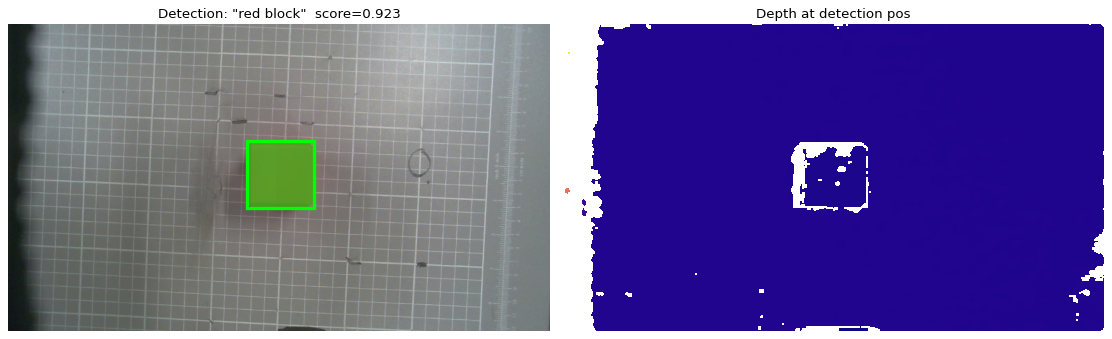

  ⏱ detect (gemini + sam3 + tableZ): 1.5s  (elapsed 1.5s)
  [FAST] Memory confident (n=109, std=0.50N) — skipping DeliGrasp
  Rough object position: (-0.191, -0.571, 0.074)
  Scan 1 (detection pos): 8562 pts
  [center] iter 0: object 12px from image centre
  [center] centred ✓
  ⏱ top-down centering: 1.9s  (elapsed 3.4s)
  Scan (top-down): 6103 pts  fill=82%  OK
  Merged (aligned 1.6mm pose/calib drift): 8562 + 6103 → 12638 pts, anchored to detection scan


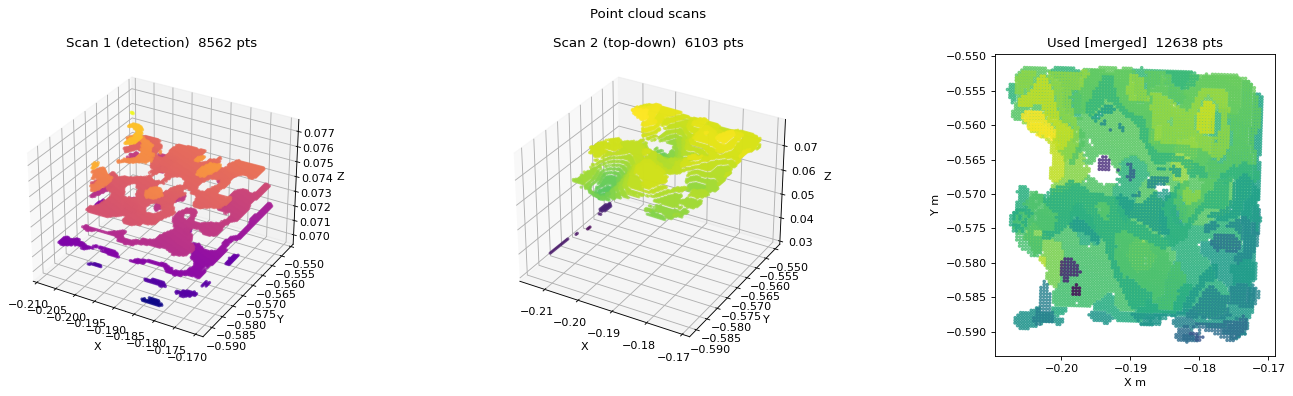

  ⏱ point cloud (build + merge): 1.4s  (elapsed 4.8s)
  [shape model] n=50: major=49±2mm minor=27±3mm h=38mm ratio=1.82
  [shape model] confident (n=50) — using accumulated shape 49x27mm ratio=1.82 for the grasp decision (robust to single-scan noise)
  PCA: major=48.7mm  minor=26.7mm  angle=95.4deg  [symmetric]
  reason: gemini: symmetric (ratio=1.82)
  [graspgenx] inference started in background — PCA viz runs concurrently
  [orientation memory] 32/33 held near 95° (keeping angle)
  [angle memory] learned correction -44.8deg from 47 held grasps (q=0.86, spread=51.8deg)


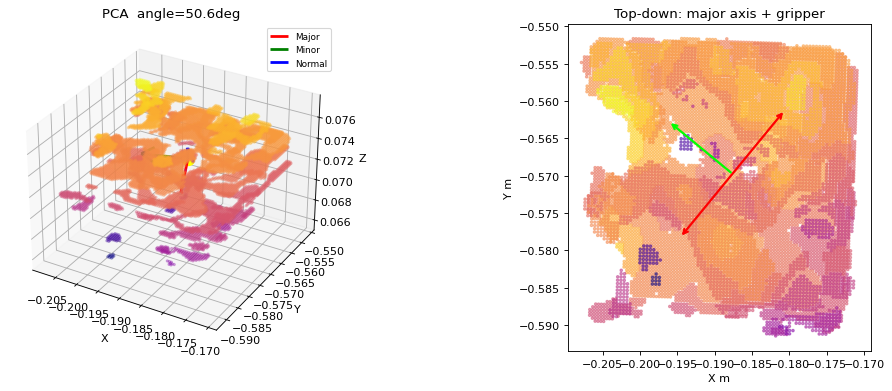

  grasp XY -> PCA cloud centroid (-0.188,-0.570)  [mask centroid was (-0.191,-0.570)]
  p_obj=(-0.188,-0.570,0.073)
  TABLE_Z=37.4mm  obj_h=35.7mm  grasp_off=17.9mm
  arc_comp=+26.2mm (close_ap≈32mm)  new gfz=81.5mm
Safety OK  approach_fz=0.173m  grasp_fz=0.082m
  ⏱ PCA + angle + viz: 3.8s  (elapsed 8.6s)
  [ggx sym] 0 centre grasps (r<9mm)
  [graspgenx] GraspGenX centre (-0.187,-0.570) vs mask centroid (-0.188,-0.570) Δ=1mm — using MASK centroid for grasp XY
  [graspgenx] 20 grasps, 4 on-object | 2 clusters: ['63°', '45°'] centre=(-0.187,-0.570) lat=2534ms


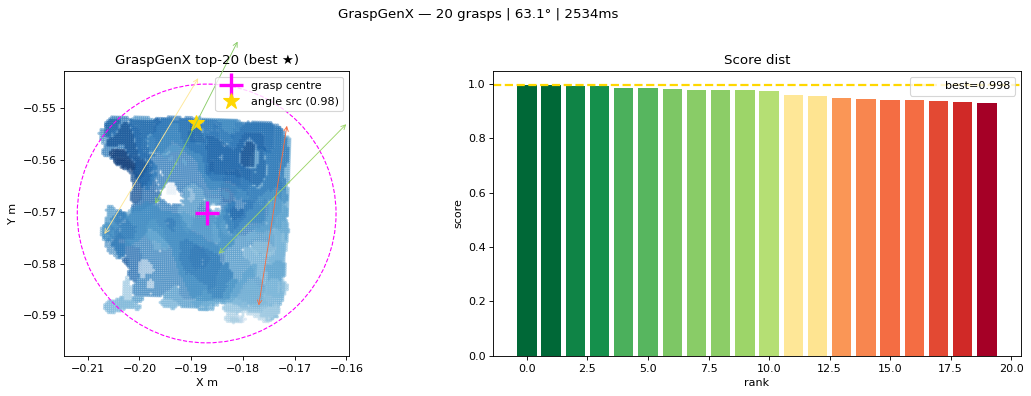

  ⏱ graspgenx (wait + viz): 2.7s  (elapsed 11.3s)


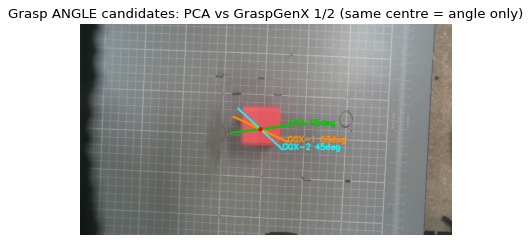

  [arbiter] 2 candidates: [('PCA', '51°'), ('GGX-1', '63°')]
  [arbiter] Gemini chose PCA = 44.6deg: Option A is a better grasp as it is more aligned with the narrowest span of the block compared to Option B.


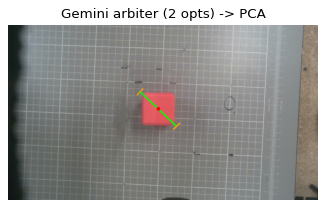

  ⏱ gemini arbiter: 1.3s  (elapsed 12.6s)
  grasp XY = PCA centroid (-0.188,-0.570)  [OBB @ 45° would be (-0.188,-0.569), Δ=1mm — NOT applied]
  gripper offset correction @ 45°: (+11.0,-10.5)mm (arm translates to it first, THEN rotates)
  Memory prior: 16.0N ± 0.50N (n=109 grasps, source=string)  visual match 0.94

Grasp params: force=16.0N  cap=16.0N  thresh=8.00N
  ⏱ deligrasp wait + force + poses: 0.2s  (elapsed 12.8s)
Approach...
  ⏱ approach + rotate moves: 5.1s  (elapsed 17.9s)
  grasp-angle correction: camera swing 15mm -> target (-0.190,-0.586)
Descend...
  [recentre] grasp-height check: 14mm from PCA target (diagnostic, not moving)
  ⏱ descend + recentre: 5.2s  (elapsed 23.0s)
  attempt 1: ap=38.2mm  F=7.906N  → slip
  attempt 2: ap=37.9mm  F=8.104N  → contact
  ⏱ grasp close loop: 7.6s  (elapsed 30.6s)
Lifting...
  ⏱ lift: 2.6s  (elapsed 33.2s)
  [gripcal] finger offset 12.7mm -> small step, offset now (-0.5,-14.7)mm ✓ close
  [model] saved cloud #121 for "red block" (12638 p

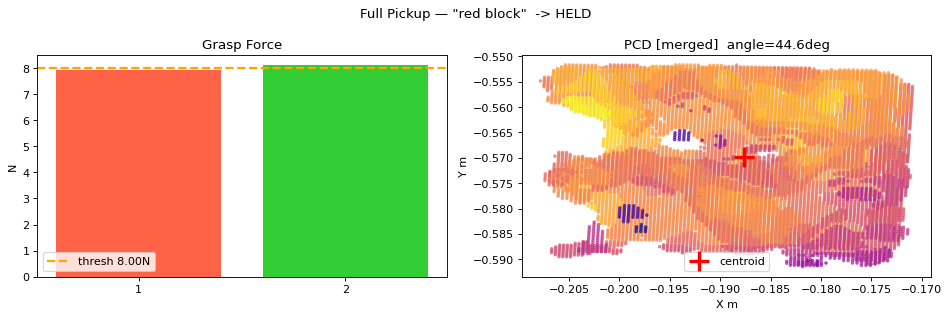


Result: contact  ap=37.9mm  F=8.104N  attempts=2
  ⏱ place + wrap-up: 9.1s  (elapsed 42.2s)

──── Section timings (slowest first) ────
     9.1s  place + wrap-up
     7.6s  grasp close loop
     5.2s  descend + recentre
     5.1s  approach + rotate moves
     3.8s  PCA + angle + viz
     2.7s  graspgenx (wait + viz)
     2.6s  lift
     1.9s  top-down centering
     1.5s  detect (gemini + sam3 + tableZ)
     1.4s  point cloud (build + merge)
     1.3s  gemini arbiter
     0.2s  deligrasp wait + force + poses
    42.2s  TOTAL


In [11]:
import importlib, pointcloud_utils; importlib.reload(pointcloud_utils)
from pointcloud_utils import (build_segmented_pcd, denoise_pcd, analyse_pcd,
                              grasp_rotation_matrix, check_view_quality, top_layer,
                              smart_grasp_angle, augment_cloud_for_graspgenx,
                              rank_grasp_angles_visual)
import open3d as o3d

print('=== Full Pickup ===')
# ANGLE_TEST_MODE: set True (in an earlier cell or here) to sweep angles cleanly —
# it bypasses the learned orientation/angle-correction memory so the angle you
# intend is the angle that executes. Leave False for normal self-improving runs.
if 'ANGLE_TEST_MODE' not in dir(): ANGLE_TEST_MODE = False
if ANGLE_TEST_MODE: print('  [ANGLE_TEST_MODE] angle memory overrides BYPASSED')
if 'CALIB_MODE' not in dir(): CALIB_MODE = False
if CALIB_MODE: print('  [CALIB_MODE] will measure + correct the camera offset from the held block')

# ── Section timer ────────────────────────────────────────────────────────────
# Logs wall-clock per section so you can see what's slow (usually the Gemini/SAM3
# calls). Summary (slowest first) prints at the end of the cell.
import time as _time
_T0 = _time.time(); _tprev = _T0; _timings = []
def _tick(_label):
    global _tprev
    _now = _time.time(); _seg = _now - _tprev; _tprev = _now
    _timings.append((_label, _seg))
    print(f'  ⏱ {_label}: {_seg:.1f}s  (elapsed {_now-_T0:.1f}s)')
# ── Setup: auto-load calibration + auto-measure TABLE_Z ──────────────────────
import pathlib as _pp, datetime as _dt
_calib_path = _pp.Path('~/magpie_control/data/last_calibration.json').expanduser()
# auto-load the saved gripper mechanical offset (TCP-local constant — see the
# APPLY MEASURED GRIPPER OFFSET cell for why this must be TCP-local, not world-frame)
if _calib_path.exists():   # ALWAYS reload — file is authoritative (stale kernel values caused the side-grasp relapse)
    try:
        import json as _jn
        _cn = _jn.load(open(_calib_path))
        if _cn.get('gripper_offset_tcp_m'):
            GRIPPER_OFFSET_TCP_M = (float(_cn['gripper_offset_tcp_m'][0]), float(_cn['gripper_offset_tcp_m'][1]))
            print(f'  [calib] loaded gripper offset ({GRIPPER_OFFSET_TCP_M[0]*1000:+.0f},'
                  f'{GRIPPER_OFFSET_TCP_M[1]*1000:+.0f})mm TCP-local')
        if _cn.get('grasp_angle_offset') is not None:
            GRASP_ANGLE_OFFSET = float(_cn['grasp_angle_offset'])
            print(f'  [calib] loaded grasp-angle bias {GRASP_ANGLE_OFFSET:+.1f}°')
    except Exception: pass
# Load the MEASURED camera clocking if we've calibrated it (fixes position-dependent
# localization — the reason a fixed offset can't handle left AND right). Always applied
# when present, not gated on z_off.
if _calib_path.exists():
    try:
        import json as _jj
        _c = _jj.load(open(_calib_path))
        if _c.get('clocking_deg') is not None:
            from magpie_control.homog_utils import homog_xform, R_krot
            _zoff = float(_c.get('z_off', _TCP_TO_CAM[2, 3]))
            _cxy  = _c.get('cam_xy_offset', [_CAM_XY_OFFSET_M[0], _CAM_XY_OFFSET_M[1]])
            _TCP_TO_CAM = homog_xform(R_krot([0, 0, 1], np.radians(_c['clocking_deg'])),
                                      [float(_cxy[0]), float(_cxy[1]), _zoff])
            _CAM_XY_OFFSET_M = (float(_cxy[0]), float(_cxy[1]))
            print(f'  [calib] loaded measured clocking Rz({_c["clocking_deg"]}°) — localization calibrated across the table')
        else:
            print('  [calib] no clocking measured yet — using default -90° (run the CLOCKING CAL cell to fix left/right)')
    except Exception as _ce2:
        print(f'  [calib] clocking load skipped: {_ce2}')
else:
    print('  [calib] no calibration file — default clocking -90°')


# ── Pre-flight gripper check ─────────────────────────────────────────────────
# AX-12 servos overload-shutdown their torque after ~1-2s holding against
# resistance — a recurring failure mode, not an edge case. Without this, a
# leftover shutdown state from the END of the previous pickup silently carries
# into the very first open_g() below.
try:
    node.clear_err()
    print('  [gripper] torque re-enabled, ready')
except Exception as _gerr:
    print(f'  [gripper] clear_err failed ({_gerr}) — check gripper connection')


# Ensure dependencies exist if cells 8b/8c weren't run
if 'gc' not in dir():
    from google import genai
    gc = genai.Client(api_key=os.environ.get('GEMINI_API_KEY', ''))

if 'sam3_query' not in dir():
    import socket as _sock, json, base64, tempfile
    def sam3_query(img_rgb, query, sock_path=SAM3_SOCK):
        tmp = tempfile.mktemp(suffix='.jpg')
        cv2.imwrite(tmp, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        try:
            with _sock.socket(_sock.AF_UNIX, _sock.SOCK_STREAM) as s:
                s.connect(sock_path)
                s.sendall((json.dumps({'image': tmp, 'query': query}) + '\n').encode())
                raw = b''
                while True:
                    chunk = s.recv(65536)
                    if not chunk: break
                    raw += chunk
            d = json.loads(raw.decode().strip())
            if 'error' in d: raise RuntimeError(d['error'])
            boxes  = np.array(d['boxes'],  dtype=float)
            scores = np.array(d['scores'], dtype=float)
            mask   = None
            if d.get('mask_b64') and len(boxes) > 0:
                raw2 = base64.b64decode(d['mask_b64'])
                h, w = d['mask_shape']
                mask = np.frombuffer(raw2, dtype=np.uint8).reshape(h, w).astype(bool)
            return boxes, scores, mask
        finally:
            if os.path.exists(tmp): os.unlink(tmp)

# ── ~1.35x speedup on all UR5 moves (velocity + acceleration) ────────────────
# Scale every moveL's speed & accel without touching each call site or re-creating the
# node. Guarded so re-running this cell does not stack the multiplier.
MOVE_SPEEDUP = 1.35
if not getattr(node, '_speed_patched', False):
    _orig_move = node.move
    def _fast_move(mat, spd=0.08, acc=0.2, _o=_orig_move, _k=MOVE_SPEEDUP):
        return _o(mat, spd=spd * _k, acc=acc * _k)
    node.move = _fast_move
    node._speed_patched = True
    print(f'  [speed] UR5 moves scaled x{MOVE_SPEEDUP} (velocity + accel)')

# ── Diagnostic plots: skip during data collection to save ~1-3s/grasp ────────
# The pickup renders ~7 matplotlib figures per grasp (detection, clouds, GraspGenX,
# arbiter, angle-compare, summary) — for a human watching, pure overhead in a 100-episode
# run. Set SHOW_VIZ=False to skip RENDERING (figures are closed instead of drawn); the
# grasp logic is IDENTICAL and the functional Gemini calls (arbiter, reward judge) still
# run. Toggle back to True anytime — the original plt.show is restored.
SHOW_VIZ = True
if not hasattr(plt, '_orig_show'):
    plt._orig_show = plt.show
plt.show = plt._orig_show if SHOW_VIZ else (lambda *a, **k: plt.close('all'))

# ── V1 data collection: SEPARATE LeRobot dataset + run counter ───────────────
# This V0 run is stored in its OWN dataset (rsync just V0 to NSF), separate from the main
# magpie/grasp set. Memory (gm) is UNCHANGED — it still learns normally. Optionally set
# V1_LABEL (e.g. 'tile5_45deg') before a run to tag that episode in the dataset.
V1_DATASET_ROOT = '~/magpie_control/data/lerobot_v1'
V1_REPO_ID      = 'magpie/v1'
V1_LABEL        = ''
# Automation flags — set by the AUTO-COLLECT cell at the bottom; default = normal manual run.
if 'AUTO_RECORD' not in dir(): AUTO_RECORD = True            # False = scatter/reset pass (no save)
if 'AUTO_PLACE_RANDOM' not in dir(): AUTO_PLACE_RANDOM = False  # True = place at a random spot
PLACE_HALF_M = 0.04            # random-placement box = 8cm x 8cm centred on the gripper
if AUTO_RECORD:
    V1_RUN = (V1_RUN + 1) if 'V1_RUN' in dir() else 1
    print('=' * 55)
    print(f'  V1 RUN #{V1_RUN}' + (f'   [{V1_LABEL}]' if V1_LABEL else '   (set V1_LABEL to tag it)'))
    print('=' * 55)
else:
    print('-' * 55); print('  [auto] SCATTER pass (unrecorded reset)'); print('-' * 55)

# ── 1. Snapshot + Gemini detect ───────────────────────────────────────────────
node.spin(8)
fp_color  = node.color.copy()
fp_depth  = node.depth.copy()
fp_tcp    = node.tcp.copy()
fp_ci     = node.caminfo
# V1: home is PINNED to the canonical pose (median V0 start), not 'wherever the arm is'.
# Over 225 episodes, per-episode drift would otherwise accumulate; and after any miss or
# interruption, the next episode automatically starts from the exact same home.
_CANON_HOME_VEC = [-0.1696, -0.5568, 0.4071, -3.1184, 0.0469, -0.0387]
home_pick = poses.pose_vec_to_mtrx(_CANON_HOME_VEC)
if np.linalg.norm(fp_tcp[:3, 3] - home_pick[:3, 3]) > 0.015:
    print('  [home] arm off canonical home — returning before the episode starts')
    _hs = fp_tcp.copy(); _hs[2, 3] = home_pick[2, 3]
    node.unteach(); node.move(_hs, spd=0.08); node.move(home_pick, spd=0.08); node.spin(6)
    fp_color = node.color.copy(); fp_depth = node.depth.copy(); fp_tcp = node.tcp.copy()

_, _buf = cv2.imencode('.jpg', cv2.cvtColor(fp_color, cv2.COLOR_RGB2BGR))
# If the object is locked (ACTIVE_OVERRIDE), DON'T burn a Gemini call to name it —
# we already know what it is. Saves a round-trip every grasp (no overtrigger).
if 'ACTIVE_OVERRIDE' in dir() and ACTIVE_OVERRIDE.strip():
    ACTIVE = ACTIVE_OVERRIDE.strip().lower()
    print(f'Object locked to "{ACTIVE}" (ACTIVE_OVERRIDE) — skipping Gemini detection call')
else:
    r_auto = gc.models.generate_content(
        model='gemini-2.5-flash',
        contents=[
            gtypes.Part.from_bytes(data=_buf.tobytes(), mime_type='image/jpeg'),
            'What is the main graspable object? Reply 2-4 words only, no punctuation.'
        ],
        config=gtypes.GenerateContentConfig(thinking_config=gtypes.ThinkingConfig(thinking_budget=0)))
    ACTIVE = ' '.join(r_auto.text.strip().lower().split()[:4])
    print(f'Gemini detected: "{ACTIVE}"  (set ACTIVE_OVERRIDE="name" to change)')

# ── 2. SAM3 with close-up retry ──────────────────────────────────────────────
MAX_DET_RETRIES = 3
CLOSE_STEP_M    = 0.02
_det_tcp = fp_tcp.copy()
fp_boxes = fp_scores = fp_mask = None

for _det_try in range(1 + MAX_DET_RETRIES):
    fp_boxes, fp_scores, fp_mask = sam3_query(fp_color, ACTIVE)
    if len(fp_scores) > 0 and fp_mask is not None:
        best_i = int(np.argmax(fp_scores))
        print(f'SAM3:   score={fp_scores[best_i]:.3f}  mask_px={fp_mask.sum()}'
              + (f'  (moved {_det_try*CLOSE_STEP_M*100:.0f}cm closer)' if _det_try else ''))
        break
    if _det_try < MAX_DET_RETRIES:
        print(f'  SAM3 try {_det_try+1}: no detection — moving 2cm closer...')
        _det_tcp = _det_tcp.copy(); _det_tcp[2, 3] -= CLOSE_STEP_M
        node.unteach(); node.move(_det_tcp, spd=0.05); node.spin(3)
        fp_color = node.color.copy(); fp_depth = node.depth.copy(); fp_tcp = _det_tcp
else:
    raise RuntimeError(f'SAM3: no detection for "{ACTIVE}" after {MAX_DET_RETRIES+1} tries')

# ── Depth validity check ──────────────────────────────────────────────────────
# Detection succeeding doesn't guarantee usable depth under the mask — reflective
# surfaces (e.g. red plastic) or distance can wipe out IR depth return. If that
# happens, the rough-position calc below would silently zero out and the arm
# would move to ~its own position instead of the object's. Move 5cm closer and
# retry instead of trusting a near-empty depth read.
MAX_DEPTH_RETRIES  = 2
DEPTH_STEP_M       = 0.05
MIN_VALID_DEPTH_PX = 50
for _dep_try in range(1 + MAX_DEPTH_RETRIES):
    _vd_chk = fp_depth[fp_mask].astype(float)
    _vd_chk = _vd_chk[_vd_chk > 0]
    if len(_vd_chk) >= MIN_VALID_DEPTH_PX:
        break
    if _dep_try == MAX_DEPTH_RETRIES:
        raise RuntimeError(f'Depth under "{ACTIVE}" mask still too sparse '
                            f'({len(_vd_chk)}px) after {MAX_DEPTH_RETRIES} '
                            f'{DEPTH_STEP_M*100:.0f}cm closer-moves — check for a '
                            'reflective surface or sensor occlusion.')
    print(f'  Depth try {_dep_try+1}: only {len(_vd_chk)} valid depth px under mask '
          f'— moving {DEPTH_STEP_M*100:.0f}cm closer...')
    _det_tcp = _det_tcp.copy(); _det_tcp[2, 3] -= DEPTH_STEP_M
    node.unteach(); node.move(_det_tcp, spd=0.05); node.spin(3)
    fp_color = node.color.copy(); fp_depth = node.depth.copy(); fp_tcp = _det_tcp
    _nb_dep, _ns_dep, _nm_dep = sam3_query(fp_color, ACTIVE)
    if len(_ns_dep) > 0 and _nm_dep is not None:
        fp_boxes, fp_scores, fp_mask = _nb_dep, _ns_dep, _nm_dep
        best_i = int(np.argmax(fp_scores))
    else:
        print('  SAM3 lost the object after moving closer — retrying depth check on same mask')

# ── Auto TABLE_Z from ring around detected object ─────────────────────────────
# Dilate the SAM3 mask and sample depth from the ring outside it — pure table.
# This replaces the separate clear-table TABLE_Z cell.
if TABLE_Z is None:
    import cv2 as _cv2a
    _dil = _cv2a.dilate(fp_mask.astype(np.uint8), np.ones((50,50), np.uint8)).astype(bool)
    _ring = _dil & ~fp_mask
    _ys_r, _xs_r = np.where(_ring)
    _ds_r = fp_depth[_ring].astype(float)
    _ok_r = _ds_r > 0
    if _ok_r.sum() > 100:
        _xs_r, _ys_r, _ds_r = _xs_r[_ok_r], _ys_r[_ok_r], _ds_r[_ok_r] / 1000.
        _fx_r, _fy_r = fp_ci.k[0], fp_ci.k[4]
        _cx_r, _cy_r = fp_ci.k[2], fp_ci.k[5]
        _Xc = (_xs_r - _cx_r) * _ds_r / _fx_r
        _Yc = (_ys_r - _cy_r) * _ds_r / _fy_r
        _T_r = fp_tcp @ _TCP_TO_CAM
        _Zw = _T_r[2,0]*_Xc + _T_r[2,1]*_Yc + _T_r[2,2]*_ds_r + _T_r[2,3]
        TABLE_Z = float(np.median(_Zw))
        HARD_FLOOR_Z = TABLE_Z
        print(f'  [auto] TABLE_Z={TABLE_Z*1000:.1f}mm  HARD_FLOOR_Z={HARD_FLOOR_Z*1000:.1f}mm')
    else:
        raise RuntimeError('Auto TABLE_Z failed — not enough table visible around object. '
                           'Move arm closer or run cell 8 on a clear table.')
else:
    print(f'  [TABLE_Z] using pre-measured {TABLE_Z*1000:.1f}mm')

# ── Show: detection ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
vis0 = fp_color.copy()
vis0[fp_mask] = (vis0[fp_mask]*.4 + np.array([0,200,0])*.6).astype(np.uint8)
x1b,y1b,x2b,y2b = fp_boxes[best_i].astype(int)
# Save detection crop NOW — fp_color will be overwritten with scan 2 image later
_det_crop = fp_color[
    max(0,y1b):min(fp_color.shape[0],y2b),
    max(0,x1b):min(fp_color.shape[1],x2b)]
ax1.imshow(vis0)
ax1.add_patch(patches.Rectangle((x1b,y1b),x2b-x1b,y2b-y1b,lw=3,ec='lime',fc='none'))
ax1.set_title(f'Detection: "{ACTIVE}"  score={fp_scores[best_i]:.3f}'); ax1.axis('off')
d0 = fp_depth.astype(float); d0[d0==0] = np.nan
ax2.imshow(d0, cmap='plasma'); ax2.set_title('Depth at detection pos'); ax2.axis('off')
plt.tight_layout(); plt.show()

_tick('detect (gemini + sam3 + tableZ)')
# ── DeliGrasp: fire in background so it overlaps GraspGenX + arbiter + moves ─
# It only needs the detection image and object name — no angle, no arm state.
# By the time we need force params (right before grip), it's already done.
import threading as _threading
_NUM = r'([0-9]+(?:\.[0-9]+)?)'
def _parse_dg(txt):
    import re as _re2
    m = _re2.search(r'\[start of description\](.*?)\[end of description\]', txt, _re2.DOTALL | _re2.IGNORECASE)
    b = m.group(1) if m else txt
    def g(pat): h = _re2.search(pat, b, _re2.IGNORECASE); return float(h.group(1)) if h else None
    mass = g(rf'mass of {_NUM} grams'); k = g(rf'spring constant of {_NUM} Newtons')
    mu = g(rf'friction coefficient of {_NUM}')
    fi = min(16., max(0.15, (mass/1000*9.81)/max(mu,1e-6))) if mass and mu else 3.
    fc = float(np.clip((k or 1000.)*0.008, 1.0, 16.))
    fi = min(fi, fc)
    return dict(mass_g=mass, k=k, mu=mu, initial_force=fi, force_cap=fc)
_DG_SYS = (
    'Control a robot gripper. Max 16N min 0.15N, max aperture 105mm min 1mm.\n'
    'Rules: replace [PNUM] with a positive number, {CHOICE:[a,b]} with one choice.\n'
    'Spring constant must be between 20 N/m (very soft/squishy) and 2000 N/m (hard rubber/stiff plastic).\n'
    '[start of description]\n'
    '* This is a new grasp.\n'
    '* In accordance with the user instruction, this grasp should be [GRASP_DESCRIPTION].\n'
    '* This is a complete grasp.\n'
    '* This grasp is for an object with {CHOICE:[high,medium,low]} weight.\n'
    '* The object has an approximate mass of [PNUM] grams\n'
    '* This grasp is for an object with {CHOICE:[high,medium,low]} compliance.\n'
    '* The object has an approximate spring constant of [PNUM] Newtons per meter.\n'
    '* The gripper and object have an approximate friction coefficient of [PNUM]\n'
    '* This grasp should set the goal aperture to [PNUM] mm.\n'
    '* If the gripper slips, this grasp should close an additional [PNUM] mm.\n'
    '* If the gripper slips, this grasp should increase the output force by [PNUM] Newtons.\n'
    '[end of description]')
_fast_prior = gm.get_prior(ACTIVE, _det_crop) if 'gm' in dir() else {'n': 0, 'force_mean': None, 'force_std': None}
# Progressive: lean on DeliGrasp LESS as records accumulate. Skip it once memory is
# confident (low Kalman std) — which happens sooner the more consistent the object is,
# not at a fixed 5-grasp wall. Need >=2 grasps to have a std estimate at all. Combined
# with the n-weighted blend below, DeliGrasp's influence tapers smoothly: full -> 50%
# (n=2) -> 25% (n=3) -> skipped once std<0.6.
_skip_deligrasp = (_fast_prior['n'] >= 2 and
                   _fast_prior.get('force_std') is not None and
                   _fast_prior['force_std'] < 0.6)
_dg_result = {}
_dg_thread = None
if _skip_deligrasp:
    _mf = _fast_prior['force_mean']
    _dg_result['GP'] = {'mass_g': None, 'mu': None, 'k': None,
                        'initial_force': _mf,
                        'force_cap': float(np.clip(_mf * 2.5, _mf * 1.1, 16.))}
    print(f'  [FAST] Memory confident (n={_fast_prior["n"]}, '
          f'std={_fast_prior["force_std"]:.2f}N) — skipping DeliGrasp')
elif 'gc' in dir():
    _, _dg_raw_buf = cv2.imencode('.jpg', cv2.cvtColor(fp_color, cv2.COLOR_RGB2BGR))
    _dg_bytes = _dg_raw_buf.tobytes()   # copy now before fp_color is overwritten by scan 2
    _active_dg = str(ACTIVE)
    def _dg_worker(_bytes=_dg_bytes, _name=_active_dg, _res=_dg_result):
        try:
            _raw = gc.models.generate_content(
                model='gemini-2.5-flash',
                contents=[gtypes.Part.from_bytes(data=_bytes, mime_type='image/jpeg'),
                          f'Pick up the {_name}. Assess material and compliance from the image. '
                          'Respond using the exact template, replacing all [PNUM] fields with numbers.'],
                config=gtypes.GenerateContentConfig(system_instruction=_DG_SYS, thinking_config=gtypes.ThinkingConfig(thinking_budget=0))).text
            _gp = _parse_dg(_raw)
            try:
                _st = gtypes.Tool(google_search=gtypes.GoogleSearch())
                _sl = gc.models.generate_content(
                    model='gemini-2.5-flash',
                    contents=[gtypes.Part.from_bytes(data=_bytes, mime_type='image/jpeg'),
                              f'Object: "{_name}". Search for real specs. Report ONLY:\n'
                              'MASS_G: <grams>\nFRICTION: <vs rubber 0.25-0.8>\nSTIFFNESS: <N/m 20-2000>'],
                    config=gtypes.GenerateContentConfig(tools=[_st], thinking_config=gtypes.ThinkingConfig(thinking_budget=0))).text
                import re as _re3
                _sm = _re3.search(rf'MASS_G:\s*{_NUM}', _sl, _re3.I)
                _sf = _re3.search(rf'FRICTION:\s*{_NUM}', _sl, _re3.I)
                _sk = _re3.search(rf'STIFFNESS:\s*{_NUM}', _sl, _re3.I)
                if _sm: _gp['mass_g'] = float(_sm.group(1))
                if _sf: _gp['mu'] = float(np.clip(float(_sf.group(1)), 0.15, 1.0))
                if _sk: _gp['k'] = float(np.clip(float(_sk.group(1)), 20., 2000.))
                if _gp.get('mass_g') and _gp.get('mu'):
                    _gp['initial_force'] = min(16., max(0.15, (_gp['mass_g']/1000.*9.81)/max(_gp['mu'],1e-6)))
                    if _gp.get('k'):
                        _ki = float(_gp['k'])
                        _gp['force_cap'] = float(np.clip(_ki * (0.012 if _ki < 400 else 0.025), 1.0, 16.))
            except Exception as _se2:
                _res['search_warn'] = str(_se2)
            _res['GP'] = _gp
        except Exception as _dge:
            _res['error'] = str(_dge)
    _dg_thread = _threading.Thread(target=_dg_worker, daemon=True)
    _dg_thread.start()
    print('  [DeliGrasp] fired in background — running while GraspGenX + arm move...')

_fx, _fy = fp_ci.k[0], fp_ci.k[4]; _cx, _cy = fp_ci.k[2], fp_ci.k[5]

# ── 3. Rough object XY — used only to position arm above object ───────────────
_ys1, _xs1 = np.where(fp_mask)
_u1, _v1   = int(_xs1.mean()), int(_ys1.mean())
_vd1 = fp_depth[fp_mask].astype(float); _vd1 = _vd1[_vd1 > 0]
_dm1 = float(np.median(_vd1)) / 1000. if len(_vd1) > 0 else 0.
_p_cam1   = np.array([(_u1-_cx)*_dm1/_fx, (_v1-_cy)*_dm1/_fy, _dm1])
_p_world1 = (fp_tcp @ _TCP_TO_CAM @ np.array([*_p_cam1, 1.]))[:3]
print(f'  Rough object position: ({_p_world1[0]:.3f}, {_p_world1[1]:.3f}, {_p_world1[2]:.3f})')

# Build scan 1 PCD from detection position — always, so we can merge later
_hint1 = (fp_tcp @ _TCP_TO_CAM @ np.array([
    (_u1-_cx)*_dm1/_fx, (_v1-_cy)*_dm1/_fy, _dm1, 1.]))[:3]
_, _pcd_raw1 = build_segmented_pcd(fp_mask, fp_depth, fp_ci.k, fp_tcp, _TCP_TO_CAM)
_, pts_cln1  = denoise_pcd(_pcd_raw1, hint=_hint1)
print(f'  Scan 1 (detection pos): {len(pts_cln1)} pts')

# ── 4. Move directly above object and scan from top-down ─────────────────────
tcp2 = fp_tcp.copy()
tcp2[0, 3] = _p_world1[0]; tcp2[1, 3] = _p_world1[1]
tcp2[2, 3] = _p_world1[2] + APPROACH_H + GRIPPER_LEN
# ── Start VLA recording HERE, at the FIRST manipulation move, so the episode captures the
# full reach (move-above + centering), not just the approach/descent. Perception before this
# has no arm motion; the short model-compute gap after centering logs as stationary frames,
# which end_episode already flags via its 'moving' count. ────────────────────────────────
if 'vla_rec' not in dir():
    try:
        from vla_recorder import VLARecorder
        vla_rec = VLARecorder(node, root=V1_DATASET_ROOT, repo_id=V1_REPO_ID, fps=10,
                              trim_static=True,   # V1: drop arm-idle compute-gap frames
                              rerun=(VLA_RERUN if 'VLA_RERUN' in dir() else None))
    except Exception as _vre:
        print(f'  [VLA] recorder unavailable: {_vre}')
        class _NullRec:
            def __getattr__(self, _): return lambda *a, **k: None
        vla_rec = _NullRec()
if AUTO_RECORD:
    vla_rec.start_episode(f'pick up the {ACTIVE}')
vla_rec.set_action(tcp2, grip=104.)  # V1 aperture-mm action: 104 = open (reach phase)
node.unteach(); node.move(tcp2, spd=0.08); node.spin(4)

# ── Closed-loop centering: physically move the arm to put the object under the ──
# camera before scanning. The per-grasp offset is random (calib drift / depth noise),
# so servo it out instead of grasping off-centre. Damped (0.7) to avoid overshoot,
# and divergence-guarded: if the offset stops shrinking (e.g. clocking is badly off),
# it stops rather than spiralling. Uses the principal point as the centre target.
_cpx, _cpy = fp_ci.k[2], fp_ci.k[5]
_cfx, _cfy = fp_ci.k[0], fp_ci.k[4]
color2 = node.color.copy(); depth2 = node.depth.copy(); mask2 = fp_mask
_best_off = float('inf'); _moved = False
for _ci in range(4):
    node.spin(4)
    _c2 = node.color.copy(); _d2 = node.depth.copy()
    _, _, _m = sam3_query(_c2, ACTIVE)
    if _m is None or not _m.any():
        print('  [center] object not seen this view'); break
    # commit a CONSISTENT (mask, depth) pair captured at the current tcp2
    color2, depth2, mask2, _moved = _c2, _d2, _m, False
    _cys, _cxs = np.where(mask2)
    _ou, _ov = float(_cxs.mean()), float(_cys.mean())
    _off = float(np.hypot(_ou - _cpx, _ov - _cpy))
    print(f'  [center] iter {_ci}: object {_off:.0f}px from image centre')
    if _off < 25.:
        print('  [center] centred ✓'); break
    if _off > _best_off + 5.:
        print('  [center] not converging — stopping (consider recalibrating)'); break
    _best_off = min(_best_off, _off)
    _cvd = depth2[mask2].astype(float); _cvd = _cvd[_cvd > 0]
    if len(_cvd) < 30:
        print('  [center] depth too sparse to move — proceeding'); break
    _cd = float(np.median(_cvd)) / 1000.
    # pixel offset -> world XY move that brings the object under the optical axis
    _R_tot = (tcp2 @ _TCP_TO_CAM)[:3, :3]
    _dw = _R_tot @ np.array([(_ou - _cpx) * _cd / _cfx,
                             (_ov - _cpy) * _cd / _cfy, 0.])
    tcp2 = tcp2.copy()
    tcp2[0, 3] += float(_dw[0]) * 0.7
    tcp2[1, 3] += float(_dw[1]) * 0.7
    node.unteach(); node.move(tcp2, spd=0.05); vla_rec.set_action(tcp2, grip=104.); time.sleep(0.3); _moved = True
# If we exited right after a move, the committed mask/depth are from the pre-move
# pose — re-capture once so the scan below is consistent with the settled tcp2.
if _moved:
    node.spin(4)
    color2 = node.color.copy(); depth2 = node.depth.copy()
    _, _, _m = sam3_query(color2, ACTIVE)
    if _m is not None and _m.any(): mask2 = _m

_tick('top-down centering')
_ys2, _xs2 = np.where(mask2)
_u2, _v2   = int(_xs2.mean()), int(_ys2.mean())
_vd2 = depth2[mask2].astype(float); _vd2 = _vd2[_vd2 > 0]
_dm2 = float(np.median(_vd2)) / 1000. if len(_vd2) > 0 else 0.
_hint2 = (tcp2 @ _TCP_TO_CAM @ np.array([
    (_u2-_cx)*_dm2/_fx, (_v2-_cy)*_dm2/_fy, _dm2, 1.]))[:3]
_, pcd_raw2 = build_segmented_pcd(mask2, depth2, fp_ci.k, tcp2, _TCP_TO_CAM)
_, pts_cln2 = denoise_pcd(pcd_raw2, hint=_hint2)
vq2 = check_view_quality(pts_cln2, mask2, depth2)
print(f'  Scan (top-down): {vq2["n_pts"]} pts  fill={vq2["fill"]:.0%}  {"OK" if vq2["ok"] else "BLOCKED"}')

# SAM3 and GraspGenX COEXIST on the 8 GB card (measured: SAM3 ~3.9 GB + GraspGenX
# ~0.8 GB, peak ~4.8 GB during inference — ~3 GB headroom). Both stay warm all
# session; no VRAM swap, so SAM3 stays available for the centering check + live
# recalibration, and the GraspGenX server is reused (no per-grasp reload).

# ── Merge scan 1 + scan 2 for better coverage on irregular objects ────────
# Top-down sees the footprint; detection-side sees profile/height.
# Merged PCA is more accurate for fruits, asymmetric shapes.
if vq2['ok'] and len(pts_cln1) >= 10 and len(pts_cln2) >= 10:
    # Two scans, two arm poses: the detection scan, then the arm moved CLOSER for a
    # top-down scan. Each is already transformed to world by its own TCP pose, but
    # residual hand-eye calibration drift still offsets the SAME object between them.
    # Align scan 2 onto scan 1 by XY centroid (scan 1 = detection scan = the trusted
    # localisation) so the object OVERLAYS into one dense cloud instead of ghosting,
    # then merge. This accounts for the move-closer difference in the merged result.
    _c1 = pts_cln1.mean(axis=0)
    _c2 = pts_cln2.mean(axis=0)
    _reg_err = float(np.linalg.norm((_c1 - _c2)[:2]))
    _shift = np.array([_c1[0] - _c2[0], _c1[1] - _c2[1], 0.])   # align XY, keep Z
    pts_cln2a = pts_cln2 + _shift
    _pcd_both = o3d.geometry.PointCloud()
    _pcd_both.points = o3d.utility.Vector3dVector(np.vstack([pts_cln1, pts_cln2a]))
    _, pts_use = denoise_pcd(_pcd_both, hint=_c1)
    mask_use = mask2
    src_label = 'merged'
    print(f'  Merged (aligned {_reg_err*1000:.1f}mm pose/calib drift): '
          f'{len(pts_cln1)} + {len(pts_cln2)} → {len(pts_use)} pts, '
          f'anchored to detection scan')
elif vq2['ok']:
    pts_use = pts_cln2; mask_use = mask2; src_label = 'top-down'
else:
    print('  Top-down blocked — using detection-position scan only')
    pts_use = pts_cln1 if len(pts_cln1) >= len(pts_cln2) else pts_cln2
    mask_use = fp_mask; src_label = 'side-only'

# ── Stray-point radius filter (catches what DBSCAN misses) ────────────────────
# A few misclassified mask pixels (ruler marks, shadow) can survive denoise as a
# small cluster that BRIDGES into the main blob via noise points — DBSCAN then sees
# ONE connected cluster and drops nothing, letting the stray pull the centroid off.
# Fix: use the object's own known size (shape model, or a safe default for an
# unmeasured object) as a hard radius bound around the ROBUST (median) centre —
# points further out physically cannot be part of THIS object, regardless of
# connectivity.
if len(pts_use) > 20:
    _rad_mm = None
    if 'gm' in dir():
        _sh = gm.get_shape(ACTIVE)
        if _sh: _rad_mm = _sh['major_mm'] * 0.75  # half-diag margin
    if _rad_mm is None:
        _rad_mm = 60.  # generous default before a shape model exists (ext not computed yet here)
    _med_xy = np.median(pts_use[:, :2], axis=0)
    _dist_mm = np.hypot(pts_use[:, 0] - _med_xy[0], pts_use[:, 1] - _med_xy[1]) * 1000.
    _rkeep = _dist_mm <= _rad_mm
    if _rkeep.sum() >= 0.5 * len(pts_use) and (~_rkeep).sum():
        print(f'  Radius filter: dropped {int((~_rkeep).sum())} pts beyond {_rad_mm:.0f}mm '
              f'of robust centre (stray cluster)')
        pts_use = pts_use[_rkeep]

# Drop disconnected stray clusters (IR-stereo depth artifacts, table specks) that
# survive statistical denoise — keep only the largest connected blob (the object),
# so the centroid and PCA see the object alone, not a phantom clump beside it.
# Tightened eps (8mm, was 12mm) so a stray cluster doesn't bridge into the main
# blob through a couple of noise points.
if len(pts_use) > 40:
    _pcf = o3d.geometry.PointCloud()
    _pcf.points = o3d.utility.Vector3dVector(pts_use)
    _lbl = np.asarray(_pcf.cluster_dbscan(eps=0.008, min_points=10))
    if _lbl.max() >= 0:
        _big  = np.bincount(_lbl[_lbl >= 0]).argmax()
        _keep = _lbl == _big
        if _keep.sum() >= 0.5 * len(pts_use):     # safety: never nuke the object
            _drop = int((~_keep).sum())
            if _drop:
                pts_use = pts_use[_keep]
                print(f'  Cluster filter: dropped {_drop} stray pts '
                      f'({_lbl.max()+1} clusters → kept largest)')

if len(pts_use) < 3:
    raise RuntimeError(f'Too few points after denoise: {len(pts_use)}')

# ── Show: scan 1 | scan 2 | merged comparison ───────────────────────────
fig = plt.figure(figsize=(18, 5))
_ax1 = fig.add_subplot(131, projection='3d')
if len(pts_cln1) > 0:
    _ax1.scatter(pts_cln1[:,0], pts_cln1[:,1], pts_cln1[:,2],
                 c=pts_cln1[:,2], cmap='plasma', s=4, alpha=.6)
_ax1.set_title(f'Scan 1 (detection)  {len(pts_cln1)} pts')
_ax1.set_xlabel('X'); _ax1.set_ylabel('Y'); _ax1.set_zlabel('Z')
_ax2 = fig.add_subplot(132, projection='3d')
if len(pts_cln2) > 0:
    _ax2.scatter(pts_cln2[:,0], pts_cln2[:,1], pts_cln2[:,2],
                 c=pts_cln2[:,2], cmap='viridis', s=4, alpha=.6)
_ax2.set_title(f'Scan 2 (top-down)  {len(pts_cln2)} pts')
_ax2.set_xlabel('X'); _ax2.set_ylabel('Y'); _ax2.set_zlabel('Z')
_ax3 = fig.add_subplot(133)
_ax3.scatter(pts_use[:,0], pts_use[:,1], c=pts_use[:,2], cmap='viridis', s=5, alpha=.7)
_ax3.set_title(f'Used [{src_label}]  {len(pts_use)} pts')
_ax3.set_xlabel('X m'); _ax3.set_ylabel('Y m'); _ax3.set_aspect('equal')
plt.suptitle('Point cloud scans'); plt.tight_layout(); plt.show()


fp_color = color2; fp_depth = depth2; fp_tcp = tcp2; fp_mask = mask2

_tick('point cloud (build + merge)')
# ── 5. PCA + mask-based angle (stripe-free) ───────────────────────────────────
pts_top  = top_layer(pts_use)  # PCA/angle only — do NOT augment from pts_top; augment_cloud_for_graspgenx uses raw pts_use for correct height
pca      = analyse_pcd(pts_top)
cen      = pca['centroid']
ext      = pca['extent_m']
obj_w_mm = ext[1] * 1000.
# ── Shape model: accumulated geometry from past grasps of THIS object ─────────
# A single top-down scan is noisy; the model is the fuller picture built over many
# grasps. If it's confident and the current grip-width disagrees a lot, trust it.
_shape = gm.get_shape(ACTIVE) if 'gm' in dir() else None
if _shape:
    _hs = f' h={_shape["height_mm"]:.0f}mm' if _shape['height_mm'] is not None else ''
    print(f'  [shape model] n={_shape["n"]}: major={_shape["major_mm"]:.0f}±{_shape["major_std"]:.0f}mm '
          f'minor={_shape["minor_mm"]:.0f}±{_shape["minor_std"]:.0f}mm{_hs} ratio={_shape["ratio"]:.2f}')
    # Recognized object with a STABLE accumulated shape → use it for the whole grasp
    # DECISION, not just width. A cube's shape doesn't change, so one noisy scan giving a
    # spurious major/minor ratio can pick the wrong strategy (symmetric vs short/long-side)
    # and a bad angle. Override the PCA extents with the accumulated ones (keep the CURRENT
    # scan's orientation/angle — only the object's SHAPE is reused, not its rotation).
    if _shape['n'] >= 3 and _shape['minor_std'] < 6. and _shape['major_std'] < 8.:
        _new_ext = np.array(pca['extent_m'], dtype=float).copy()
        _new_ext[0] = _shape['major_mm'] / 1000.
        _new_ext[1] = _shape['minor_mm'] / 1000.
        pca['extent_m'] = _new_ext; ext = _new_ext
        obj_w_mm = float(_shape['minor_mm'])
        print(f'  [shape model] confident (n={_shape["n"]}) — using accumulated shape '
              f'{_shape["major_mm"]:.0f}x{_shape["minor_mm"]:.0f}mm ratio={_shape["ratio"]:.2f} '
              f'for the grasp decision (robust to single-scan noise)')
    elif _shape['n'] >= 3 and _shape['minor_std'] < 6. and obj_w_mm > 0:
        _wdev = abs(obj_w_mm - _shape['minor_mm']) / max(_shape['minor_mm'], 1e-6)
        if _wdev > 0.40:
            print(f'  [shape model] current minor {obj_w_mm:.0f}mm is {_wdev*100:.0f}% off model '
                  f'{_shape["minor_mm"]:.0f}mm — scan likely noisy, using model width')
            obj_w_mm = float(_shape['minor_mm'])
ang, strategy, reason = smart_grasp_angle(
    pca, object_name=ACTIVE, image_rgb=fp_color,
    gemini_client=gc, mask=mask_use)
print(f'  PCA: major={ext[0]*1e3:.1f}mm  minor={ext[1]*1e3:.1f}mm  angle={ang:.1f}deg  [{strategy}]')
print(f'  reason: {reason}')
_ang_pca = float(ang)   # raw PCA angle — baseline for the angle feedback loop
# ── GraspGenX: fire in background thread IMMEDIATELY — runs concurrently with ──
# PCA viz + depth centroid + safety check below (~350ms of free GPU time). The
# server is warm (preloaded at startup, coexists with SAM3 in VRAM), so this is
# just a ~0.5s ZMQ inference overlapped with the main-thread PCA work.
_GMETHOD_raw = GRASP_METHOD if 'GRASP_METHOD' in dir() else 'pca'
_GMETHOD     = _GMETHOD_raw
_ang_ggx     = None
_ggx_clusters = []
_ggx_result  = {}   # thread writes here; main thread reads after join

def _ggx_worker(_pts=pts_use, _mask=mask_use, _tcp=fp_tcp, _k=fp_ci.k,
                _tz=TABLE_Z, _cam_h=CAMERA_MOUNT_Z_OFFSET_M, _strat=strategy,
                _res=_ggx_result):
    try:
        sys.path.insert(0, os.path.expanduser('~/magpie_control/scripts/grasp_detectors'))
        from grasp_detectors import socket_detector as _sdc
        _det = {'graspgen': _sdc.graspgen,
                'graspgenx': _sdc.graspgenx}[_GMETHOD_raw]()
        if not _det.available():
            # Server should be preloaded at startup. If it isn't, give it a bounded
            # wait that covers the measured ~10s cold-start — NOT a 60s stall with
            # the arm staged over the object. If it doesn't come up, fall back to PCA.
            print(f'  [{_GMETHOD_raw}] server not up — starting (≤15s, else PCA fallback)...')
            _ggx_sh = os.path.expanduser('~/magpie_control/scripts/run_graspgenx_server.sh')
            if 'PROCS' in dir():
                PROCS['graspgenx'] = subprocess.Popen(
                    ['bash', _ggx_sh],
                    stdout=open('/tmp/log_graspgenx.txt', 'w'), stderr=subprocess.STDOUT)
            for _wi in range(15):
                time.sleep(1.0)
                if _det.available(): print(f'  [{_GMETHOD_raw}] ready in {_wi+1}s'); break
            else:
                _res['error'] = 'server failed to start'; return
        _pts_ggx = augment_cloud_for_graspgenx(_pts, _tz, extra_height_m=_cam_h)
        _gr = _det.detect(_pts_ggx, mask=_mask, tcp=_tcp, intrinsics=_k)
        if not _gr.best:
            _res['no_grasp'] = True; return
        _obj_ctr = np.median(_pts[:, :2], axis=0)
        _obj_rad = float(np.percentile(
            np.hypot(_pts[:,0]-_obj_ctr[0], _pts[:,1]-_obj_ctr[1]), 90)) + 0.005
        _valid = [g for g in _gr.grasps
                  if np.hypot(g.pose[0,3]-_obj_ctr[0], g.pose[1,3]-_obj_ctr[1]) <= _obj_rad]
        # Prefer grasps whose gripper pose lands within the object radius. But GraspGenX
        # gives ANGLED/side grasps whose pose XY sits off to the side of the contact point,
        # so the strict filter can reject them all — in that case DON'T drop GGX; fall back
        # to the grasps CLOSEST to the object centre (still the most on-object candidates).
        if _valid:
            _pool = _valid
        else:
            _pool = sorted(_gr.grasps,
                           key=lambda g: np.hypot(g.pose[0,3]-_obj_ctr[0], g.pose[1,3]-_obj_ctr[1])
                          )[:min(6, len(_gr.grasps))]
        if _strat == 'symmetric':
            _ctr_r = _obj_rad * 0.35
            _ctr_ok = [g for g in _pool
                       if np.hypot(g.pose[0,3]-_obj_ctr[0],
                                   g.pose[1,3]-_obj_ctr[1]) < _ctr_r]
            _pool = _ctr_ok if _ctr_ok else _pool
            print(f'  [ggx sym] {len(_ctr_ok)} centre grasps (r<{_obj_rad*0.35*1000:.0f}mm)')
        _clusters = []
        _used = [False] * len(_pool)
        _near = None
        for _gi, _g in enumerate(sorted(_pool, key=lambda g: -g.score)):
            if _used[_gi]: continue
            _a = float(_g.angle_deg()) % 180.
            if _near is None: _near = _g
            for _gj, _go in enumerate(_pool):
                if _used[_gj]: continue
                if min(abs((float(_go.angle_deg())%180.)-_a), 180.-abs((float(_go.angle_deg())%180.)-_a)) < 15.:
                    _used[_gj] = True
            _clusters.append(min(_a, 90.))
            if len(_clusters) >= 2: break   # top 2 clusters only (3rd was consistently the weak/diagonal one)
        _res.update(dict(
            gr=_gr, valid=_valid, obj_ctr=_obj_ctr, obj_rad=_obj_rad,
            clusters=_clusters, ang_ggx=_clusters[0] if _clusters else None,
            near=_near if _near else _gr.best, pool=_pool,
        ))
    except Exception as _e:
        _res['error'] = str(_e)

_ggx_thread = None
if _GMETHOD != 'pca':
    _ggx_thread = _threading.Thread(target=_ggx_worker, daemon=True)
    _ggx_thread.start()
    print(f'  [{_GMETHOD}] inference started in background — PCA viz runs concurrently')


# ── Orientation feedback loop (VLA) — avoid orientations that slipped before ──
# Symmetric-ish footprint (minor/major > 0.75) means rotating 90deg is a valid
# alternative grip. If this angle has a losing track record, switch it.
_sym = (ext[1] / max(ext[0], 1e-6)) > 0.75
_adv = gm.get_angle_advice(ACTIVE, ang, symmetric=_sym) if ('gm' in dir() and not ANGLE_TEST_MODE) else None
if _adv and _adv['overridden']:
    print(f'  [orientation memory] {_adv["reason"]}')
    print(f'    -> overriding angle {ang:.1f}deg -> {_adv["recommend_angle"]:.1f}deg')
    ang = float(_adv['recommend_angle'])
elif _adv and _adv['n_at_proposed'] > 0:
    print(f'  [orientation memory] {_adv["reason"]} (keeping angle)')

# ── Visual grasp verification — draw the grasp axis on the camera image (projected
#    from world coords so it lines up with the object) and let Gemini confirm or
#    correct it. Catches degenerate cases (e.g. diagonal grasp on a square cube).
# ── Gripper-angle feedback loop — apply the learned PCA->good-angle correction.
#    Pose-invariant delta learned from past HELD grasps of this object. Once
#    confident, trust it and skip the per-grasp Gemini visual check (like the
#    DeliGrasp skip for force). The visual check still runs while unconfident,
#    and every outcome is recorded so the correction keeps improving.
_skip_visual = False
_acorr = gm.get_angle_correction(ACTIVE) if ('gm' in dir() and not ANGLE_TEST_MODE) else None
if _acorr:
    print(f'  [angle memory] learned correction {_acorr["delta"]:+.1f}deg from '
          f'{_acorr["n"]} held grasps (q={_acorr["mean_quality"]:.2f}, '
          f'spread={_acorr["spread_deg"]:.1f}deg)')
    ang = float((_ang_pca + _acorr['delta']) % 90.)
    if _acorr['confident']:
        _skip_visual = True
        print(f'    confident -> applying learned angle {ang:.1f}deg, skipping visual check')

_grasp_vis = None; _grasp_verdict = 'none'; _grasp_check_reason = ''
# Gemini visual check MOVED below: it now runs AFTER GraspGenX so it arbitrates the
# FINAL PCA-vs-GraspGenX candidates right before descent (no more verify-then-override).

# ── Show: PCA ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
axp1 = fig.add_subplot(121, projection='3d')
axp1.scatter(pts_use[:,0], pts_use[:,1], pts_use[:,2], c=pts_use[:,2], cmap='plasma', s=4, alpha=.3)
ptc  = pts_use - cen
ev, evec = np.linalg.eigh(np.cov(ptc.T))
idx  = np.argsort(ev)[::-1]; evec = evec[:,idx]; sc_e = np.sqrt(np.abs(ev[idx]))
for i, (lbl, col) in enumerate(zip(['Major','Minor','Normal'],['red','green','blue'])):
    axp1.quiver(*cen, *(evec[:,i]*sc_e[i]), color=col, lw=2.5, label=lbl)
axp1.scatter(*cen, color='yellow', s=120, zorder=5)
axp1.set_xlabel('X'); axp1.set_ylabel('Y'); axp1.set_zlabel('Z')
axp1.set_title(f'PCA  angle={ang:.1f}deg'); axp1.legend(fontsize=8)
axp2 = fig.add_subplot(122)
axp2.scatter(pts_use[:,0], pts_use[:,1], c=pts_use[:,2], cmap='plasma', s=5, alpha=.5)
t_a = np.radians(ang); L_a = sc_e[0]
axp2.annotate('', xy=(cen[0]+L_a*np.cos(t_a), cen[1]+L_a*np.sin(t_a)),
              xytext=(cen[0]-L_a*np.cos(t_a), cen[1]-L_a*np.sin(t_a)),
              arrowprops=dict(arrowstyle='<->', color='red', lw=2))
axp2.annotate('', xy=(cen[0]+L_a*np.cos(t_a+np.pi/2), cen[1]+L_a*np.sin(t_a+np.pi/2)),
              xytext=cen[:2], arrowprops=dict(arrowstyle='->', color='lime', lw=2))
axp2.set_aspect('equal'); axp2.set_xlabel('X m'); axp2.set_ylabel('Y m')
axp2.set_title('Top-down: major axis + gripper')
import io as _io
_pca_buf = _io.BytesIO()
fig.savefig(_pca_buf, format='jpeg', dpi=80, bbox_inches='tight')
_pca_plot_bytes = _pca_buf.getvalue()
plt.tight_layout(); plt.show()

# ── 6. Depth centroid + TABLE_Z ───────────────────────────────────────────────
ys, xs = np.where(fp_mask)
u, v   = int(xs.mean()), int(ys.mean())
valid  = fp_depth[fp_mask].astype(float); valid = valid[valid > 0]
dm     = float(np.median(valid)) / 1000.
p_cam  = np.array([(u-_cx)*dm/_fx, (v-_cy)*dm/_fy, dm])
T      = fp_tcp @ _TCP_TO_CAM
p_obj  = (T @ np.array([*p_cam, 1.]))[:3]
# Grasp XY from the MERGED cloud centroid (anchored to the detection scan), NOT the
# top-down depth centroid — top-down localisation drifts under calibration error and
# was missing the object. Keep Z from the depth centroid for the grasp-depth calc.
# Grasp XY = SAM3 MASK centroid (p_obj above), NOT the point-cloud centroid.
# Depth drops out on shiny/red surfaces, so the cloud only covers part of the
# block and its centroid (mean/median) gets pulled to the covered side — that's
# the 'grips the edge not the centre' bug. The mask sees the full silhouette and
# only needs ONE median depth for distance, so it stays centred under dropout.
# Grasp XY = point-cloud PCA centroid (cen) — what centred reliably in the PCA-only
# era. Reverted from the mask-centroid/OBB experiments that regressed it on a block.
_xy_mask = (float(p_obj[0]), float(p_obj[1]))
p_obj[0], p_obj[1] = float(cen[0]), float(cen[1])
print(f'  grasp XY -> PCA cloud centroid ({p_obj[0]:.3f},{p_obj[1]:.3f})  '
      f'[mask centroid was ({_xy_mask[0]:.3f},{_xy_mask[1]:.3f})]')
print(f'  p_obj=({p_obj[0]:.3f},{p_obj[1]:.3f},{p_obj[2]:.3f})')

# Always use TABLE_Z measured at notebook start (before object placed).
# Re-estimating from live scene is unreliable with object in view.
_tz = TABLE_Z
if _tz is None:
    print('  [!] TABLE_Z not set — using HARD_FLOOR_Z. Run the Z-scan cell first.')
    _tz = HARD_FLOOR_Z
obj_height_est = max(p_obj[2] - _tz, 0.010)
# Shape model = VISION extents only. Do NOT record the gripper aperture as width — the
# AX-12 aperture scale is biased ~-20mm vs reality (reads ~26mm on the ~46mm block); mixing
# scales poisoned the model, shrank the pre-close gap, and the fingers shoved the block
# during descent (the 2026-07-06 side-grasp relapse).
if 'gm' in dir() and len(pts_use) > 40:   # decent scan → add to the object's shape model
    gm.record_shape(ACTIVE, ext[0]*1000., ext[1]*1000., obj_height_est*1000.)
grasp_off      = float(np.clip(obj_height_est / 2., 0.010, 0.040))
print(f'  TABLE_Z={_tz*1000:.1f}mm  obj_h={obj_height_est*1000:.1f}mm  grasp_off={grasp_off*1000:.1f}mm')

# ── 7. Safety check ───────────────────────────────────────────────────────────
afz = p_obj[2] + APPROACH_H
gfz = p_obj[2] - grasp_off
# Raise gfz to compensate for fingertip arc-drop during close.
# Fingers swing down ~21mm fully open→closed; compensate based on expected grip aperture.
_grip_ap_mm  = float(np.clip(obj_w_mm + 5., 5., 90.))   # uses model-corrected width
_arc_comp_m  = fingertip_drop(105., _grip_ap_mm)
gfz         += _arc_comp_m
print(f'  arc_comp=+{_arc_comp_m*1000:.1f}mm (close_ap≈{_grip_ap_mm:.0f}mm)  new gfz={gfz*1000:.1f}mm')
assert afz >= HARD_FLOOR_Z, f'Approach fingertip {afz:.3f}m below floor'
assert gfz >= HARD_FLOOR_Z, f'Grasp fingertip {gfz:.3f}m below floor'
print(f'Safety OK  approach_fz={afz:.3f}m  grasp_fz={gfz:.3f}m')

_tick('PCA + angle + viz')
# ── Join GraspGenX thread + visualise results ────────────────────────────────
if _ggx_thread is not None:
    _ggx_thread.join(timeout=30.)
    if _ggx_thread.is_alive():
        print(f'  [{_GMETHOD}] timed out — falling back to PCA'); _GMETHOD = 'pca'
    elif _ggx_result.get('error'):
        print(f'  [{_GMETHOD}] error: {_ggx_result["error"]} — falling back to PCA'); _GMETHOD = 'pca'
    elif _ggx_result.get('no_grasp'):
        print(f'  [{_GMETHOD}] no grasp — falling back to PCA'); _GMETHOD = 'pca'
    else:
        _gr      = _ggx_result['gr']
        _valid   = _ggx_result['valid']
        _obj_ctr = _ggx_result['obj_ctr']
        _obj_rad = _ggx_result['obj_rad']
        _ggx_clusters = _ggx_result['clusters']
        _ang_ggx = _ggx_result['ang_ggx']
        _near    = _ggx_result['near']
        # GraspGenX contributes the ANGLE only. Its _obj_ctr is the median of the
        # SAME partial cloud, so it inherits the same depth-dropout side-bias — do
        # NOT move the grasp XY to it. Keep the mask-centroid XY chosen above.
        _ggx_ctr_x, _ggx_ctr_y = float(_obj_ctr[0]), float(_obj_ctr[1])
        _cx, _cy = _ggx_ctr_x, _ggx_ctr_y   # for the GGX scatter plot below only
        _dggx_mm = float(np.linalg.norm([_ggx_ctr_x - p_obj[0], _ggx_ctr_y - p_obj[1]])) * 1000.
        print(f'  [{_GMETHOD}] GraspGenX centre ({_ggx_ctr_x:.3f},{_ggx_ctr_y:.3f}) '
              f'vs mask centroid ({p_obj[0]:.3f},{p_obj[1]:.3f}) Δ={_dggx_mm:.0f}mm '
              f'— using MASK centroid for grasp XY')
        print(f'  [{_GMETHOD}] {_gr.n} grasps, {len(_valid)} on-object | '
              f'{len(_ggx_clusters)} clusters: {[f"{a:.0f}°" for a in _ggx_clusters]} '
              f'centre=({_cx:.3f},{_cy:.3f}) lat={1000*_gr.latency_s:.0f}ms')
        if not _valid:
            print(f'  [{_GMETHOD}] no grasps strictly on-object — using the {len(_ggx_result.get("pool",[]))} closest to centre instead')
        # Visualise (must be on main thread)
        _topk = _gr.grasps[:min(30, _gr.n)]
        _sc   = np.array([g.score for g in _topk])
        _pos  = np.array([[g.pose[0,3], g.pose[1,3]] for g in _topk])
        _cls  = np.array([[g.pose[0,0], g.pose[1,0]] for g in _topk])
        _norm_sc = plt.Normalize(_sc.min(), _sc.max()); _cmap_sc = plt.cm.RdYlGn
        _hm = 0.018
        fig, (ax_g, ax_s) = plt.subplots(1, 2, figsize=(14, 5))
        ax_g.scatter(pts_use[:,0], pts_use[:,1], c=pts_use[:,2], cmap='Blues', s=4, alpha=0.35)
        for _i, (p2, c2, s2) in enumerate(zip(_pos, _cls, _sc)):
            ax_g.annotate('', xy=(p2[0]+c2[0]*_hm, p2[1]+c2[1]*_hm),
                          xytext=(p2[0]-c2[0]*_hm, p2[1]-c2[1]*_hm),
                          arrowprops=dict(arrowstyle='<->', color=_cmap_sc(_norm_sc(s2)),
                                         lw=3 if _i==0 else 0.8))
        ax_g.plot(_cx, _cy, '+', color='magenta', ms=22, mew=3, label='grasp centre')
        ax_g.add_patch(plt.Circle((_cx,_cy),_obj_rad,fill=False,color='magenta',ls='--',lw=1))
        ax_g.plot(_near.pose[0,3], _near.pose[1,3], '*', color='gold', ms=15,
                  label=f'angle src ({_near.score:.2f})')
        ax_g.set_xlabel('X m'); ax_g.set_ylabel('Y m'); ax_g.set_aspect('equal')
        ax_g.set_title(f'GraspGenX top-{len(_topk)} (best ★)'); ax_g.legend()
        _all_sc = sorted([g.score for g in _gr.grasps], reverse=True)[:30]
        ax_s.bar(range(len(_all_sc)), _all_sc,
                 color=[_cmap_sc(_norm_sc(s)) for s in _all_sc])
        ax_s.axhline(_gr.best.score, color='gold', ls='--', lw=2,
                     label=f'best={_gr.best.score:.3f}')
        ax_s.set_xlabel('rank'); ax_s.set_ylabel('score'); ax_s.set_title('Score dist'); ax_s.legend()
        _angttl = f'{_ang_ggx:.1f}°' if _ang_ggx is not None else 'no on-object angle'
        plt.suptitle(f'GraspGenX — {_gr.n} grasps | {_angttl} | {1000*_gr.latency_s:.0f}ms')
        plt.tight_layout(); plt.show()

_tick('graspgenx (wait + viz)')
# (angle-candidates image removed — superseded by the unified ANGLE DECISION view below)
# ── Gemini MULTI-CANDIDATE ARBITER ──────────────────────────────────────────────
# Build a pool of up to 4 clamped angle candidates, show them all to Gemini as
# labelled lines on the real image, and let it rank + fine-tune the best one.
# Candidates: PCA-short, PCA-long (perpendicular), then up to 2 GraspGenX clusters.
# All angles are wrist-clamped (0–90°) so Gemini sees exactly what will execute.
_ang_arb_choice = 'pca-only'
if 'gc' in dir() and not _skip_visual:
    try:
        from pointcloud_utils import verify_grasp_angle_visual
        _half = float(max(0.03, ext[0] * 0.6))
        _ang_pca_arb = min(float(ang) % 180., 90.)   # wrist-clamped PCA angle
        # Build candidate pool: PCA + GraspGenX clusters (all clamped)
        _arb_candidates = [('PCA', _ang_pca_arb)]
        if '_ggx_clusters' in dir():
            for _ci, _ca in enumerate(_ggx_clusters[:2]):
                # only add if meaningfully different from existing candidates
                if all(abs((_ca - _ea + 90.) % 180. - 90.) > 8.
                       for _, _ea in _arb_candidates):
                    _arb_candidates.append((f'GGX-{_ci+1}', _ca))
        print(f'  [arbiter] {len(_arb_candidates)} candidates: '
              f'{[(l, f"{a:.0f}°") for l, a in _arb_candidates]}')
        if len(_arb_candidates) >= 2:
            _ang_arb, _chosen, _grasp_check_reason, _gv = rank_grasp_angles_visual(
                fp_color, cen, _arb_candidates, fp_tcp, _TCP_TO_CAM, fp_ci.k,
                object_name=ACTIVE, gemini_client=gc, half_len_m=_half, mask=mask_use)
            _ang_arb_choice = _chosen; _grasp_verdict = f'CHOSE {_chosen}'
            print(f'  [arbiter] Gemini chose {_chosen} = {_ang_arb:.1f}deg: {_grasp_check_reason}')
            ang = min(float(_ang_arb) % 180., 90.)
            _grasp_title = f'Gemini arbiter ({len(_arb_candidates)} opts) -> {_chosen}'
        else:
            # Only one candidate — just verify/nudge it
            _ang_new, _grasp_verdict, _grasp_check_reason, _gv = verify_grasp_angle_visual(
                fp_color, cen, ang, fp_tcp, _TCP_TO_CAM, fp_ci.k,
                object_name=ACTIVE, gemini_client=gc, half_len_m=_half, mask=mask_use)
            _ang_arb_choice = 'pca'
            if _grasp_verdict.startswith('ROTATE') and abs((_ang_new - ang + 90.) % 180. - 90.) > 3.:
                print(f'  [grasp check] corrected {ang:.1f}deg -> {_ang_new:.1f}deg')
                ang = min(float(_ang_new) % 180., 90.)
            print(f'  [grasp check] {_grasp_verdict}: {_grasp_check_reason}')
            _grasp_title = f'Grasp check [{_grasp_verdict}] — green=close axis, orange=fingers'
        # (arbiter image folded into the unified ANGLE DECISION view below)
    except Exception as _ve:
        print(f'  [arbiter skipped: {_ve}]')

_tick('gemini arbiter')
# ── 8. Poses ──────────────────────────────────────────────────────────────────
ang = min(float(ang) % 180., 90.)   # wrist safety: clamp FIRST (grasp centre uses it)
# ── V1 ANGLE CONTRACT: grasp angle MUST match the block's flat-face orientation ──
# (DATA_STANDARD step 2). V0 let the arbiter pick ~90° regardless of block angle → 42/62
# episodes at 90° → the policy froze on 45° blocks (mode averaging). minAreaRect gives the
# true edge orientation; for a square-ish footprint, snap to the nearest flat-face axis.
try:
    import cv2 as _cv2ff
    def _angdiff90(a, b):
        return min((a - b) % 90., (b - a) % 90.)
    _flat_cloud = _flat_mask = None
    # source 1: world-projected point cloud (same frame as `ang`)
    if len(pts_use) >= 8:
        _ffp = np.asarray(pts_use[:, :2], dtype=np.float32) * 1000.
        (_bw, _bh), _brect = _cv2ff.minAreaRect(_ffp)[1:]
        if min(_bw, _bh) / max(_bw, _bh, 1e-6) > 0.72:
            _flat_cloud = float(_brect) % 90.
    # source 2: SAM3 mask silhouette — clean under depth dropout (red plastic kills IR).
    # minAreaRect angle θ in image coords maps to the pipeline convention as (90−θ)%90
    # (same mapping as mask_grasp_angle: image (dx,dy) -> atan2(−dy,dx)+90°).
    if 'mask_use' in dir() and mask_use is not None and mask_use.any():
        _mys, _mxs = np.where(mask_use)
        if len(_mxs) >= 50:
            _mpts = np.stack([_mxs, _mys], 1).astype(np.float32)
            (_mw, _mh), _mrect = _cv2ff.minAreaRect(_mpts)[1:]
            if min(_mw, _mh) / max(_mw, _mh, 1e-6) > 0.72:
                _flat_mask = (90. - float(_mrect)) % 90.
                # ── V2 ladder cross-check / drive ──────────────────────────
                try:
                    import sys as _v2sys
                    if '/home/user/magpie_control/src' not in _v2sys.path:
                        _v2sys.path.insert(0, '/home/user/magpie_control/src')
                    from magpie_control.v2.grasp_ladder import propose as _v2_propose
                    _v2p    = _v2_propose((mask_use > 0).astype('uint8') * 255)
                    globals()['_v2_ladder_method'] = _v2p.method
                    _v2flat = (90. - _v2p.grasp_yaw_deg) % 90.
                    _v2dev  = min((_v2flat - _flat_mask) % 90, (_flat_mask - _v2flat) % 90)
                    print(f'  [ladder] {_v2p.method}: flat={_v2flat:.0f} vs minAreaRect={_flat_mask:.0f} (dev {_v2dev:.0f} deg)')
                    if globals().get('LADDER_DRIVES_ANGLE') and _v2p.method != 'minAreaRect':
                        print(f'  [ladder] DRIVING (non-box): _flat_mask {_flat_mask:.0f} -> {_v2flat:.0f}')
                        _flat_mask = _v2flat
                except Exception as _v2e:
                    print(f'  [ladder] cross-check skipped: {_v2e}')
    # pick the flat-face reference: agree -> cloud; disagree >15° -> MASK wins (dropout-immune)
    _flat = _flat_cloud
    if _flat_cloud is not None and _flat_mask is not None and _angdiff90(_flat_cloud, _flat_mask) > 15.:
        print(f'  [angle contract] cloud rect {_flat_cloud:.0f}° vs mask rect {_flat_mask:.0f}° '
              f'disagree — trusting the MASK (depth dropout suspected)')
        _flat = _flat_mask
    elif _flat_cloud is None:
        _flat = _flat_mask
    if _flat is not None:
        _dflat = _angdiff90(ang, _flat)
        if _dflat > 8.:
            print(f'  [angle contract] {ang:.0f}° is {_dflat:.0f}° off the flat face -> snapping to {_flat:.0f}°')
            ang = _flat
        else:
            print(f'  [angle contract] ✓ within {_dflat:.0f}° of the flat face ({_flat:.0f}°)')
except Exception as _ffe:
    print(f'  [angle contract] snap skipped: {_ffe}')
# ── V1.1 BOUNDARY CANONICALIZATION (the 0-degree fix) ────────────────────────
# The mod-90 flat-face angle is DISCONTINUOUS at the 0/90 boundary: a straight block reads
# 0.3 deg or 89.7 deg on pixel noise alone, so the expert demonstrated BOTH "stay at 0" and
# "rotate 90" on identical scenes (15 vs 45 episodes) -> imitation mode-averaged -> the
# policy rotated ~43 deg on straight blocks (all 3 eval failures). For symmetric footprints
# resolve the boundary deterministically: a reading near 90 executes as ang-90 (~0 rotation,
# physically identical grasp). Mid-angle conventions are untouched (no new divergence with
# the existing 229 episodes).
try:
    _symm = False
    if '_flat_mask' in dir() and _flat_mask is not None: _symm = True
    if '_flat_cloud' in dir() and _flat_cloud is not None: _symm = True
    if _symm and ang > 84.:
        print(f'  [angle canon] symmetric footprint at the 0/90 boundary: {ang:.1f} deg -> {ang-90.:.1f} deg (identical grasp, minimal rotation)')
        ang = ang - 90.
except Exception as _ce:
    print(f'  [angle canon] skipped: {_ce}')
_angle_dev_flat = None
try:
    if '_flat' in dir() and _flat is not None:
        _angle_dev_flat = float(min((ang - _flat) % 90., (_flat - ang) % 90.))
except Exception: pass
# Fixed angle-bias correction (consistent per-grasp offset = calibration, self-tuned in
# cell 8 from the judge's angle read, same idea as the XY offset). Clamp keeps it in range.
# V1: GRASP_ANGLE_OFFSET bias REMOVED — the flat-face snap above is the deterministic
# angle authority (a stale +8° bias was skewing snapped angles; the judge-fed anglecal
# that maintained it is unreliable off-axis and is disabled in V1).
# Grasp CENTRE = midpoint of the object's extent ALONG THE CLOSING AXIS, not the
# silhouette centroid. Fingers close along [cos,sin](ang); centring on the extent
# midpoint seats the object symmetrically BETWEEN the jaws. Equals the centroid for a
# square, but for irregular shapes the centroid drifts off the closing line → lopsided
# grip. _cdir/_cperp/_obb_centre are reused by the post-descent recentre below.
_ca = np.radians(ang)
_cdir  = np.array([np.cos(_ca), np.sin(_ca)])     # closing axis (world XY)
_cperp = np.array([-_cdir[1], _cdir[0]])          # finger-length axis
def _obb_centre(_xy):
    _pa = _xy @ _cdir; _pp = _xy @ _cperp
    return (0.5*(np.percentile(_pa,2)+np.percentile(_pa,98))) * _cdir + \
           (0.5*(np.percentile(_pp,2)+np.percentile(_pp,98))) * _cperp
# ── Tunable grasp-position nudge (fix the systematic 'closes in the wrong spot') ──
# Shifts the grasp target in WORLD XY. Dial it in a few grasps while watching: try
# ±0.01 on each axis, see which way the fingers move on the block, home in on centre.
_gc_xy = _obb_centre(pts_use[:, :2])   # diagnostic only; kept for the recentre check
_dctr_mm = float(np.hypot(_gc_xy[0]-p_obj[0], _gc_xy[1]-p_obj[1]))*1000.
print(f'  grasp XY = PCA centroid ({p_obj[0]:.3f},{p_obj[1]:.3f})  '
      f'[OBB @ {ang:.0f}° would be ({_gc_xy[0]:.3f},{_gc_xy[1]:.3f}), Δ={_dctr_mm:.0f}mm — NOT applied]')
ap = tcp2.copy()
ap[0, 3] = p_obj[0]; ap[1, 3] = p_obj[1]
ap[2, 3] = p_obj[2] + APPROACH_H + GRIPPER_LEN
# ── ANGLE DECISION — one image: every candidate + the EXECUTED angle ─────────
# thin lines = proposals (PCA noise-prone on squares; GGX clusters; arbiter pick);
# gray = measured flat-face reference; THICK MAGENTA = what actually executes.
try:
    from pointcloud_utils import project_world_to_pixel as _dv_p2px
    _dv = cv2.cvtColor(fp_color, cv2.COLOR_RGB2BGR).copy()
    _dv_items = []
    if '_ang_pca' in dir():                _dv_items.append((f'PCA {_ang_pca:.0f}', float(_ang_pca) % 180., (0, 200, 0), 2))
    if '_ggx_clusters' in dir():
        for _gi2, _ga2 in enumerate(_ggx_clusters[:2]):
            _dv_items.append((f'GGX-{_gi2+1} {_ga2:.0f}', float(_ga2), (0, 165, 255), 2))
    if '_ang_arb' in dir() and '_ang_arb_choice' in dir() and _ang_arb_choice != 'pca-only':
        _dv_items.append((f'arbiter {_ang_arb:.0f}', float(_ang_arb), (255, 255, 255), 2))
    if '_flat' in dir() and _flat is not None:
        _dv_items.append((f'flat-face {_flat:.0f}', float(_flat), (160, 160, 160), 2))
    _dv_items.append((f'EXECUTED {ang:.0f}', float(ang), (255, 0, 255), 6))
    _dv_half = float(max(0.04, ext[0] * 0.8))
    _dv_ii = lambda q: tuple(np.round(np.asarray(q)).astype(int))
    for _dv_k, (_lbl3, _a3, _col3, _th3) in enumerate(_dv_items):
        _r3 = np.radians(_a3); _d3 = np.array([np.cos(_r3), np.sin(_r3), 0.]) * _dv_half
        _pr3 = _dv_p2px(np.array([cen, cen - _d3, cen + _d3]), fp_tcp, _TCP_TO_CAM, fp_ci.k)
        cv2.line(_dv, _dv_ii(_pr3[1]), _dv_ii(_pr3[2]), _col3, _th3)
        cv2.putText(_dv, _lbl3, (8, 22 + 20 * _dv_k), cv2.FONT_HERSHEY_SIMPLEX, 0.55, _col3, 2)
    plt.figure(figsize=(7, 5)); plt.imshow(cv2.cvtColor(_dv, cv2.COLOR_BGR2RGB))
    plt.title('ANGLE DECISION: proposals (thin) -> flat-face ref (gray) -> EXECUTED (thick magenta)')
    plt.axis('off'); plt.show()
except Exception as _dve:
    print(f'  [angle-decision viz skipped: {_dve}]')
R_grasp    = grasp_rotation_matrix(ang)
ap_rot     = ap.copy(); ap_rot[:3, :3] = R_grasp
grasp_pose = ap_rot.copy(); grasp_pose[2, 3] = gfz + GRIPPER_LEN

# ── Gripper mechanical offset correction ──────────────────────────────────────
# Camera + fingers are RIGIDLY bolted to the wrist — their offset is a FIXED
# constant in the wrist's OWN rotating frame, not a fixed world-frame delta (a
# world-frame constant is wrong the moment the wrist grasps at a different angle
# than whatever angle it was measured at). GRIPPER_OFFSET_TCP_M is that constant,
# expressed in TCP-local axes (set once by the offset-measurement cell, using only
# the FIXED camera mounting rotation — never node.tcp's live/instantaneous
# rotation). Applied HERE, rotated by THIS grasp's actual R_grasp, to whichever
# poses close the gripper (ap_rot + grasp_pose share R_grasp; the earlier `ap` does
# not, so it's left alone).
if 'GRIPPER_OFFSET_TCP_M' in dir():
    _goff_world = R_grasp[:3, :3] @ np.array([GRIPPER_OFFSET_TCP_M[0], GRIPPER_OFFSET_TCP_M[1], 0.])
    # Apply the offset to ALL three poses (including the un-rotated approach `ap`), so the
    # arm TRANSLATES to the corrected XY on the approach move, then ROTATES in place to the
    # grasp angle — one action at a time (no simultaneous move + wrist-spin, easier to see).
    ap[0, 3]         -= float(_goff_world[0]); ap[1, 3]         -= float(_goff_world[1])
    ap_rot[0, 3]     -= float(_goff_world[0]); ap_rot[1, 3]     -= float(_goff_world[1])
    grasp_pose[0, 3] -= float(_goff_world[0]); grasp_pose[1, 3] -= float(_goff_world[1])
    print(f'  gripper offset correction @ {ang:.0f}°: ({-_goff_world[0]*1000:+.1f},{-_goff_world[1]*1000:+.1f})mm '
          f'(arm translates to it first, THEN rotates)')

# ── 9. Execute ────────────────────────────────────────────────────────────────
# This section is a general execution primitive — no task-specific policy.
# Force parameters come from GP (c14 / DeliGrasp). The operator or a future
# VLA policy decides whether to re-run with different parameters.

# ── Await DeliGrasp result (fired at detection time, ran in background) ──────
if _dg_thread is not None:
    _dg_thread.join(timeout=20.)
    if _dg_thread.is_alive():
        print('  [DeliGrasp] timed out after 20s — using memory prior only')
    elif _dg_result.get('search_warn'):
        print(f'  [search grounding failed: {_dg_result["search_warn"]}]')
GP = _dg_result.get('GP')
if GP and not _skip_deligrasp:
    print(f'  DeliGrasp: mass={GP.get("mass_g")}g  k={GP.get("k")}N/m  '
          f'mu={GP.get("mu")}  F0={GP.get("initial_force",0):.2f}N  '
          f'cap={GP.get("force_cap",16):.2f}N')

# Retrieve force prior from memory (DINO RAG → string → none)
_prior = gm.get_prior(ACTIVE, _det_crop) if 'gm' in dir() else {'force_mean': None, 'n': 0, 'source': 'none'}
if _prior.get('mismatch'):
    print(f'  ⚠ "{ACTIVE}" has a stored prior, but this object looks DIFFERENT '
          f'(visual match {_prior.get("match_sim") or 0:.2f}) — treating as a NEW '
          f'item: gripping cautiously, no memory shortcut.')
elif _prior['force_mean'] is not None:
    _msim = _prior.get('match_sim')
    _msim_str = f'  visual match {_msim:.2f}' if _msim is not None else ''
    print(f'  Memory prior: {_prior["force_mean"]:.1f}N ± {_prior["force_std"]:.2f}N '
          f'(n={_prior["n"]} grasps, source={_prior["source"]}){_msim_str}')

if 'GP' in dir() and GP and GP.get('mass_g') and GP.get('mu'):
    F_min       = (GP['mass_g'] / 1000. * 9.81) / (2. * max(GP['mu'], 1e-6))
    force_cap   = float(GP.get('force_cap', 16.))
    if GP.get('k'):
        _k = float(GP['k'])
        # Soft (k<400): 12mm crush limit. Stiff (k≥400): 25mm — structure handles it.
        _deform_m = 0.012 if _k < 400 else 0.025
        force_cap = float(np.clip(_k * _deform_m, 1.0, 16.))
    cf_gp       = float(np.clip(max(GP['initial_force'], F_min * 1.5), 0.5, force_cap))
    # Blend: weight memory heavier as n grows (trust prior more after 5+ grasps)
    if _prior['force_mean'] is not None and _prior['n'] >= 2:
        _w = min(0.9, _prior['n'] / 4.)   # 90% memory weight at n=4; GP is sanity-check only
        # Memory can raise force_cap — after ≥3 real grasps it's more reliable than k formula
        if _prior['n'] >= 3:
            force_cap = max(force_cap, _prior['force_mean'] * 1.5)
        cf = float(np.clip(_w * _prior['force_mean'] + (1 - _w) * cf_gp, 0.5, force_cap))
        print(f'  Blended force: {cf:.1f}N (memory {_w:.0%} + GP {1-_w:.0%})')
    else:
        cf = cf_gp
    slip_thresh = float(np.clip(F_min * 0.9, 0.15, force_cap * 0.9))
else:
    F_min = 0.
    if _skip_deligrasp and _prior.get('force_mean'):
        # Fast path: GP was intentionally bypassed — use memory force
        cf         = float(_prior['force_mean'])
        force_cap  = float(np.clip(cf * 2.5, cf * 1.1, 16.))
        slip_thresh = float(np.clip(cf * 0.5, 0.15, force_cap * 0.9))
    elif _prior.get('force_mean'):
        # No GP and no skip flag — best we have is the memory prior
        print('  [!] GP missing — run c14 first. Using memory prior.')
        cf         = float(_prior['force_mean'])
        force_cap  = 8.   # no GP, no memory — conservative cap for unknown object
        slip_thresh = float(np.clip(cf * 0.5, 0.15, force_cap * 0.9))
    else:
        print('  [!!!] No GP and no memory — fallback cf=8N.')
        cf = 4.; force_cap = 8.; slip_thresh = 0.5

print(f'\nGrasp params: force={cf:.1f}N  cap={force_cap:.1f}N  thresh={slip_thresh:.2f}N')

# ── VLA episode already started at the first manipulation move (the reach), above ──

_tick('deligrasp wait + force + poses')
# ── V1 RECOVERY EPISODES: inject a small deliberate offset into the approach; the
# re-localise below then CORRECTS it — recording correction behavior the policy can
# imitate (RaC/IntervenGen). Set by the sequencer on ~15% of episodes.
if 'RECOVERY_OFFSET_M' in dir() and RECOVERY_OFFSET_M:
    _rdx, _rdy = float(RECOVERY_OFFSET_M[0]), float(RECOVERY_OFFSET_M[1])
    for _pm in (ap, ap_rot, grasp_pose):
        _pm[0, 3] += _rdx; _pm[1, 3] += _rdy
    print(f'  [recovery] injected ({_rdx*1000:+.0f},{_rdy*1000:+.0f})mm approach offset — re-localise will correct it')
# ── Approach ──────────────────────────────────────────────────────────────────
vla_rec.set_action(ap, grip=104.)
node.clear_err(); node.open_g(); time.sleep(0.5)
print('Approach...')
node.move(ap,       spd=0.08); time.sleep(0.4); node.spin(4)
vla_rec.set_action(ap_rot, grip=104.)
node.move(ap_rot,   spd=0.05); time.sleep(0.4); node.spin(4)

_tick('approach + rotate moves')
# ── Pre-descent centering check ──────────────────────────────────────────────
# Re-detect the object after wrist rotation. If its centroid drifted off image
# centre, re-localise in world frame from THIS view and CORRECT grasp_pose's XY
# before descending — previously this only printed a warning and still
# descended on the old (possibly off-centre) XY, so the gripper closed lopsided.
# _centering_flag drives the reward gate below: 'ok' (no drift, or fixed by a
# simple re-localise, or fixed by live RECALIBRATION) vs 'unreliable' (nothing
# worked) — only 'unreliable' forces this episode to fail the reward gate.
#
# Escalation ladder when the object is off-centre after wrist rotation:
#   1. Re-localise from this view and snap grasp XY to it (cheap, no arm move).
#   2. If that jump is too large to trust (>60mm), the EXTRINSIC itself is
#      probably off, not just this one detection — call auto_calibrate() live.
#      It re-derives the camera clocking angle from a 30mm jog using the SAME
#      object already on the table (no clearing needed), updates _TCP_TO_CAM
#      for this AND future grasps this session, and persists it to disk.
#   3. Re-localise again with the fixed extrinsic and proceed normally.
#   4. Only if recalibration itself fails/is untrustworthy do we give up and
#      exclude this episode from the trainable set.
# ── Re-localise the object AT the grasp angle, then descend ──────────────
# THE FIX for left/right drift: the object used to be localised at the SCAN wrist angle,
# but the grasp happens at the GRASP angle. The camera is bolted OFF the rotation axis,
# so its localisation error is frozen at the angle it measured — it does NOT rotate with
# the grasp, while the finger offset DOES. One offset then only cancels at a single angle,
# so the grasp drifts by an angle- (hence position-) dependent amount. Re-measuring the
# object HERE, at the grasp angle, makes the camera error co-rotate with the finger offset
# → one constant offset lands centred at EVERY angle, everywhere on the table.
# This is a WORLD-frame re-localise (node.tcp @ _TCP_TO_CAM), which ACCOUNTS for the camera
# swing — NOT the old pixel-space "centering" that mistook the swing for drift and missed.
# Guarded: if it disagrees with the top-down position by >80mm it is a bad detection/depth,
# so keep the top-down target.
_centering_flag = 'ok'
try:
    node.spin(4)
    _pre_col = node.color.copy(); _pre_dep = node.depth.copy()
    _, _, _pre_mask = sam3_query(_pre_col, ACTIVE)
    if _pre_mask is not None and _pre_mask.any():
        _ys_p, _xs_p = np.where(_pre_mask)
        _kk = node.caminfo.k; _fxg, _fyg, _cxg, _cyg = _kk[0], _kk[4], _kk[2], _kk[5]
        _vdg = _pre_dep[_pre_mask].astype(float); _vdg = _vdg[_vdg > 0]
        if len(_vdg) >= 30:
            _dmg = float(np.median(_vdg)) / 1000.
            _ug, _vg = float(_xs_p.mean()), float(_ys_p.mean())
            _pcg = np.array([(_ug - _cxg) * _dmg / _fxg, (_vg - _cyg) * _dmg / _fyg, _dmg])
            _Pg = (node.tcp @ _TCP_TO_CAM @ np.array([*_pcg, 1.]))[:3]
            # DELTA, not absolute: how far the SAME feature (mask centroid) shifts between the
            # scan-angle view (_xy_mask, from line ~718) and this grasp-angle view. That shift is
            # purely the camera-error rotation (R_grasp-R_scan)*dt. Apply it to the TUNED PCA-
            # centroid target (p_obj) so we keep the "perfect" PCA localisation and add ONLY the
            # rotation correction. Using the raw mask centroid here instead injects the known
            # mask-vs-PCA ~4mm bias (that was the small downward off-centre).
            _have_ref = ('_xy_mask' in dir())
            _dx = float(_Pg[0] - _xy_mask[0]) if _have_ref else 0.0
            _dy = float(_Pg[1] - _xy_mask[1]) if _have_ref else 0.0
            _dmag = float(np.hypot(_dx, _dy))
            if _have_ref and _dmag < 0.080:
                _nx = float(p_obj[0]) + _dx; _ny = float(p_obj[1]) + _dy
                if 'GRIPPER_OFFSET_TCP_M' in dir():
                    _gwg = R_grasp[:3, :3] @ np.array([GRIPPER_OFFSET_TCP_M[0], GRIPPER_OFFSET_TCP_M[1], 0.])
                    _nx -= float(_gwg[0]); _ny -= float(_gwg[1])
                ap_rot[0, 3] = _nx; ap_rot[1, 3] = _ny
                grasp_pose[0, 3] = _nx; grasp_pose[1, 3] = _ny
                node.move(ap_rot, spd=0.05); time.sleep(0.3); node.spin(3)   # translate above corrected XY, then descend straight down
                print(f'  grasp-angle correction: camera swing {_dmag*1000:.0f}mm -> target ({_nx:+.3f},{_ny:+.3f})')
            elif _dmag >= 0.080:
                print(f'  grasp-angle swing {_dmag*1000:.0f}mm (>80) — bad detection, keeping top-down target')
            else:
                print('  grasp-angle correction: no scan-angle reference — keeping top-down target')
        else:
            print('  grasp-angle re-localise: depth too sparse — keeping top-down target')
    else:
        print('  grasp-angle re-localise: object not re-detected — keeping top-down target')
except Exception as _ctr_err:
    print(f'  grasp-angle re-localise skipped ({_ctr_err})')

print('Descend...')
vla_rec.set_action(grasp_pose, grip=104.)
node.move(grasp_pose, spd=0.05); time.sleep(0.5); node.spin(4)

# Snapshot at grasp position — what the gripper camera sees right before closing
node.spin(4)
snap_grasp = node.color.copy()

# ── Post-descent centering re-check (right before closing) ───────────────────
# The approach-height check (10cm up) can pass, yet the descent still lands the
# fingers off-centre (residual calib/kinematics) — then the first finger to touch
# SHOVES the object (visible as the object moving on close). Re-verify at grasp
# height with the depth-robust mask centroid; if off, lift, correct XY, re-descend,
# then close. Lifting first avoids dragging the open fingers across the object.
# DIAGNOSTIC ONLY (no arm move): 2 weeks ago there was no recentre and grasps landed
# centred, so we don't move the grasp off the PCA centroid here. Just report how far the
# grasp-height re-detection sits from the target, so we can SEE residual drift.
_Kc = node.caminfo.k
try:
    _, _, _gmask = sam3_query(snap_grasp, ACTIVE)
    if _gmask is not None and _gmask.any():
        _gpts, _ = build_segmented_pcd(_gmask, node.depth.copy(), _Kc, node.tcp, _TCP_TO_CAM)
        if len(_gpts) >= 30:
            _gxy = _obb_centre(_gpts[:, :2])
            _corr_mm = float(np.hypot(_gxy[0]-grasp_pose[0,3], _gxy[1]-grasp_pose[1,3])) * 1000.
            print(f'  [recentre] grasp-height check: {_corr_mm:.0f}mm from PCA target (diagnostic, not moving)')
except Exception as _rre:
    print(f'  [recentre] check skipped: {_rre}')

_tick('descend + recentre')
# ── Grasp ─────────────────────────────────────────────────────────────────────
# clear_err → set_force → close_g each attempt.
# +1N per slip is a mechanical characteristic (AX-12 needs authority to seat),
# not a policy decision. 4 attempts max.
def grip_refresh(force_n):
    node.clear_err()
    node.set_force(force_n)
    node.close_g()

# Pre-position gripper just above expected contact — less travel = more AX-12 force
_prepos_mm = max(10., obj_w_mm + 8.)
vla_rec.set_action(grasp_pose, grip=float(_prepos_mm))   # V1: pre-position IS an action now
node.set_force(cf); node.set_pos(_prepos_mm); time.sleep(0.5)

grasp_log = []
vla_rec.set_action(grasp_pose, grip=20.)  # V1: close = commanded aperture 20mm (squeeze)
_mem_confident = _prior.get('n', 0) >= 3  # memory has enough data to trust directly
for attempt in range(4):
    grip_refresh(cf)
    time.sleep(2.5)
    for _ in range(8): rclpy.spin_once(node, timeout_sec=0.15)
    s = node.gs
    if s is None: break
    status = 'contact' if s.force >= slip_thresh else 'slip'
    print(f'  attempt {attempt+1}: ap={s.position:.1f}mm  F={s.force:.3f}N  → {status}')
    grasp_log.append({'attempt': attempt+1, 'ap': s.position,
                      'force': s.force, 'cmd_force': cf, 'status': status})
    if status == 'contact': break
    cf = min(force_cap, cf + 1.0)

# Snapshot the instant the gripper has closed on the object (pre-lift) — key evidence
# for the judge: are the fingers symmetric on the object, or shoved to one side?
node.spin(3)
snap_close = node.color.copy() if node.color is not None else None

_tick('grasp close loop')
# ── Lift ──────────────────────────────────────────────────────────────────────
# Slip guard watches depth at object pixel during lift.
# Re-clamps autonomously if object drops >1mm relative to camera.
lift_force = min(force_cap, cf + 0.5)
# AX-12 torque cuts out after ~1-2s of holding and drops the object mid-lift. REFRESH the
# servo torque right before lifting (clear_err re-enables torque but resets the force limit
# to 2N, so re-assert set_force AFTER it), then lift INCREMENTALLY, re-gripping each step so
# the servo never sits overloaded long enough to trip.
node.clear_err()                    # re-enable AX-12 torque (decays while positioning)
node.set_force(lift_force)          # clear_err reset force to 2N — re-assert the real grip
time.sleep(0.15)
# Scale reclamp step with stiffness: soft objects (low k) get smaller increments
_gp_k = float(GP['k']) if 'GP' in dir() and GP and GP.get('k') else None
_force_step = float(np.clip(_gp_k / 2000., 0.15, 1.0)) if _gp_k else 0.5
node.slip_guard_enable(lift_force, slip_thresh, obj_u=int(u), obj_v=int(v), force_step=_force_step)
print('Lifting...')
vla_rec.set_action(ap_rot, grip=20.)      # V1: hold at 20mm through the lift
# Smooth single lift (torque was already refreshed via clear_err + set_force just above).
node.move(ap_rot, spd=0.05); time.sleep(0.5); node.spin(8)
s_lift = node.gs
node.slip_guard_disable()
for _ in range(5): rclpy.spin_once(node, timeout_sec=0.1)
snap_held = node.color.copy() if node.color is not None else None

_tick('lift')
# ── Parse slip guard corrections (DAgger-style training labels) ──────────
import re as _re
_sg_reclamps = [e for e in getattr(node, '_sg_events', []) if 'RECLAMP' in e]
sg_fires = len(_sg_reclamps)
true_force_label = lift_force  # default: no correction needed
if sg_fires:
    _m = _re.search(r'force now ([\d.]+)N', _sg_reclamps[-1])
    if _m:
        true_force_label = float(_m.group(1))
_init_pred = GP.get('initial_force', cf) if 'GP' in dir() and GP else cf
force_label_error = true_force_label - _init_pred
if sg_fires:
    print(f'  Slip guard fired {sg_fires}x — true force label: {true_force_label:.1f}N '
          f'(predicted {_init_pred:.1f}N, error {force_label_error:+.1f}N)')

# Held force floor = 0.6*slip_thresh, NOT the full threshold: the grip SETTLES at ~slip_thresh
# (both ~cf*0.5), so requiring the full value flips a perfectly-held grasp to DROPPED by a hair
# (7.9N vs 8.0N). Aperture is the real discriminator (held ~26mm vs a drop's near-closed read).
force_ok    = s_lift is not None and s_lift.force >= slip_thresh * 0.6
aperture_ok = s_lift is not None and s_lift.position >= obj_w_mm * 0.4
held        = force_ok and aperture_ok

# ── V1: EPISODE ENDS HERE — task = reach → grasp → lift, verified. Everything below
# (offset measurement, memory, carry/place) is unrecorded reset & bookkeeping. This
# removes the carry-tail phase ambiguity that caused V0's post-grasp dithering.
if AUTO_RECORD:
    _vla_frames = vla_rec.end_episode()
    print(f'  [VLA] episode ended at lift: {_vla_frames} frames (commit decided by reward gate)')

# ── Gripper-offset auto-measurement (from the HELD block, in mm from depth) ──
# Once clamped, the (symmetric) block sits at the gripper's mechanical centre, so
# (camera-measured block XY) − (TCP XY) is the finger offset in WORLD frame at THIS
# grasp's orientation. Rotate it into the TCP-LOCAL frame (a fixed, orientation-
# independent constant) → GRIPPER_OFFSET_TCP_M. This is measured precisely from depth,
# not eyeballed from a screenshot, and it converges in one grasp (block-minus-TCP is
# the true offset regardless of the correction already applied). Always measured as a
# diagnostic; committed + saved only when CALIB_MODE=True so a normal run can't be
# thrown off by one bad grab.
if held:
    try:
        node.spin(4)
        _hc, _hd = node.color.copy(), node.depth.copy()
        _, _, _hm = sam3_query(_hc, ACTIVE)
        if _hm is not None and _hm.any():
            _hpts, _ = build_segmented_pcd(_hm, _hd, node.caminfo.k, node.tcp, _TCP_TO_CAM)
            if len(_hpts) > 20:   # drop stray points so the held-block centroid is clean
                _hmed = np.median(_hpts[:, :2], axis=0)
                _hd_mm = np.hypot(_hpts[:,0]-_hmed[0], _hpts[:,1]-_hmed[1]) * 1000.
                _hpts = _hpts[_hd_mm <= 60.]
            if len(_hpts) > 20:
                _hmeas = np.median(_hpts[:, :2], axis=0)
                _herr  = _hmeas - node.tcp[:2, 3]                     # finger offset, WORLD frame
                _herr_mm = float(np.hypot(*_herr)) * 1000.
                _off_local = node.tcp[:3, :3].T @ np.array([_herr[0], _herr[1], 0.])  # -> TCP-local
                _meas = (float(_off_local[0]), float(_off_local[1]))
                _cur = GRIPPER_OFFSET_TCP_M if 'GRIPPER_OFFSET_TCP_M' in dir() else (0., 0.)
                _resid = float(np.hypot(_meas[0]-_cur[0], _meas[1]-_cur[1])) * 1000.
                # Self-calibrate — but only COMMIT the offset update if the grasp was
                # actually clean (block centred between the fingers). A near-miss puts the
                # block off in the jaws, corrupting this measurement — so we STASH the
                # candidate here and let cell 8 commit it only after the quality judge
                # confirms the grip was well-centred (issue != centering, good score).
                # SMALL, STABLE nudge — each grasp gets a bit closer, never a big swing.
                # Depth gives the true finger offset (block-minus-TCP); take a SMALL step
                # toward it and HARD-CLAMP the total so it can NEVER diverge (the aggressive
                # version blew up to +54mm — this cannot). Skip clearly bad grips.
                _clean = (_herr_mm < 60. and s_lift is not None
                          and s_lift.position > obj_w_mm * 0.6)
                # V1 CONSISTENCY CONTRACT: the finger offset is a MECHANICAL CONSTANT and is
                # FROZEN during collection — the self-cal has drifted it away from the known-
                # good value three times (latest: -15.2mm -> -4.9mm on 07-08 = off-centre
                # grasps). Measurement still PRINTS as a diagnostic; it never writes.
                if _clean and False:   # V1: gripcal writes DISABLED
                    _a = 0.2                              # small gentle step
                    _CLAMP = 0.030                        # 30mm hard limit — can't run away
                    _nx = _a*_meas[0] + (1-_a)*_cur[0]
                    _ny = _a*_meas[1] + (1-_a)*_cur[1]
                    GRIPPER_OFFSET_TCP_M = (max(-_CLAMP, min(_CLAMP, _nx)),
                                            max(-_CLAMP, min(_CLAMP, _ny)))
                    try:
                        import json as _jcc, pathlib as _pcc, datetime as _dcc
                        _cpp = _pcc.Path('~/magpie_control/data/last_calibration.json').expanduser()
                        _cc = _jcc.load(open(_cpp)) if _cpp.exists() else {}
                        _cc['gripper_offset_tcp_m'] = [GRIPPER_OFFSET_TCP_M[0], GRIPPER_OFFSET_TCP_M[1]]
                        _cc['saved_at'] = _dcc.datetime.now().isoformat()
                        _jcc.dump(_cc, open(_cpp, 'w'), indent=2)
                    except Exception: pass
                    print(f'  [gripcal] finger offset {_herr_mm:.1f}mm -> small step, offset now '
                          f'({GRIPPER_OFFSET_TCP_M[0]*1000:+.1f},{GRIPPER_OFFSET_TCP_M[1]*1000:+.1f})mm '
                          + ('✓ close' if _resid < 4. else '(bit closer)'))
                else:
                    print(f'  [gripcal] offset {_herr_mm:.1f}mm but grip not clean '
                          f'(ap {s_lift.position:.0f} vs {obj_w_mm:.0f}mm) -> NOT updated')
    except Exception as _ce:
        print(f'  [gripcal] measurement skipped: {_ce}')

# Stage 1 of the per-object 3D model: hoard this grasp's object cloud (world frame)
# so the offline fitter has multi-orientation views to fuse later. Data only.
if 'gm' in dir() and len(pts_use) > 40:
    _cf = gm.record_cloud(ACTIVE, pts_use, held=held, angle_deg=ang)
    if _cf: print(f'  [model] saved cloud #{gm.count_clouds(ACTIVE)} for "{ACTIVE}" '
                  f'({len(pts_use)} pts) → fitter dataset')
# ── Memory write-back — THIS is what makes the system learn across episodes ──
# Without these, force priors (DeliGrasp skip), angle memory (arbiter skip) and
# embeddings (novelty guard) never build — n stays 0 forever.
if 'gm' in dir():
    # angle outcome ALWAYS (so it learns which orientations fail too); quality is
    # patched in cell 8 once the reward score is known.
    gm.record_outcome(ACTIVE, angle_deg=ang, strategy=strategy, held=held,
                      quality=None, pca_angle=_ang_pca)
    # force prior + embedding ONLY on a held grasp (a drop's force is too low to learn).
    if held:
        gm.update(ACTIVE, float(true_force_label), image_crop=_det_crop)
        print(f'  [memory] force prior updated → n={gm.get_prior(ACTIVE)["n"]} '
              f'@ {true_force_label:.1f}N; angle outcome + embedding stored')
    else:
        print('  [memory] drop — angle outcome stored, force prior NOT updated')
    # keep a reference image of the object in its record (pull-able later)
    if '_det_crop' in dir() and _det_crop is not None and _det_crop.size:
        gm.record_image(ACTIVE, _det_crop, held=held)
print(f'Post-lift: F={s_lift.force:.3f}N  ap={s_lift.position:.1f}mm  → {"HOLDING" if held else "DROPPED"}')

# ── Result dict ───────────────────────────────────────────────────────────────
# Captures full state for VLA training data collection.
# Policy decisions (retry? different angle? more force?) are made outside this cell.
result = {
    'object':          ACTIVE,
    'held':            held,
    'centering_flag':  _centering_flag if '_centering_flag' in dir() else 'ok',
    'grasp_log':       grasp_log,
    'final_force':     s_lift.force    if s_lift else 0.,
    'final_aperture':  s_lift.position if s_lift else 0.,
    'slip_thresh':     slip_thresh,
    'lift_force_cmd':  lift_force,
    'obj_pos_world':   p_obj.tolist(),
    'grasp_angle_deg': float(ang),
    'grasp_strategy':  strategy,
    'obj_width_mm':    float(obj_w_mm),
    'angle_dev_flat':  _angle_dev_flat,   # measured deviation from the flat face (deg)
    'symmetric':           bool(_sym) if '_sym' in dir() else None,
    'angle_hist_n':        _adv['n_at_proposed']      if _adv else 0,
    'angle_hist_success':  _adv['success_at_proposed'] if _adv else 0,
    'angle_overridden':    bool(_adv['overridden'])   if _adv else False,
    'orientation_reason':  _adv['reason']             if _adv else 'no memory',
    'image_grasp_check':   _grasp_vis if '_grasp_vis' in dir() else None,
    'grasp_check_verdict': _grasp_verdict if '_grasp_verdict' in dir() else 'none',
    'grasp_check_reason':  _grasp_check_reason if '_grasp_check_reason' in dir() else '',
    'pca_angle':            _ang_pca if '_ang_pca' in dir() else None,
    'graspgenx_angle':      _ang_ggx if '_ang_ggx' in dir() else None,
    'angle_arbiter_choice': _ang_arb_choice if '_ang_arb_choice' in dir() else None,
    'angle_correction_deg': float(ang - _ang_pca) if '_ang_pca' in dir() else 0.,
    'angle_corr_confident': bool(_acorr['confident']) if _acorr else False,
    'image_detect':    fp_color,       # RGB image at detection position
    'image_close':     snap_close,     # RGB image the instant the gripper closed (pre-lift)
    'image_grasp':     snap_grasp,     # RGB image at grasp position (pre-close)
    'image_held':      snap_held,      # RGB image post-lift (shows actual grip)
    'depth_detect':    fp_depth,       # uint16 depth at detection
    'tcp_grasp':       grasp_pose.tolist(),
    'gp_mass_g':       GP.get('mass_g') if 'GP' in dir() and GP else None,
    'gp_mu':           GP.get('mu')     if 'GP' in dir() and GP else None,
    'gp_k':            GP.get('k')      if 'GP' in dir() and GP else None,
    # DAgger / HER training labels
    'sg_fires':            sg_fires,
    'sg_events':           getattr(node, '_sg_events', []).copy(),
    'true_force_label':    true_force_label,
    'force_label_error_n': force_label_error,
    'init_force_pred':     _init_pred,
}

result['grasp_method'] = _GMETHOD if '_GMETHOD' in dir() else 'pca'
if 'CMP_RESULTS' in dir():
    CMP_RESULTS.append(dict(method=result['grasp_method'], held=bool(held),
        final_force=round(float(result['final_force']), 2),
        angle_deg=round(float(ang), 1),
        aperture_mm=round(float(result['final_aperture']), 1),
        sg_fires=result.get('sg_fires', 0)))
    print(f"  [compare] logged {result['grasp_method']}: held={held}  ({len(CMP_RESULTS)} runs)")

# ALWAYS place the object down — never open the gripper at full height. The force/aperture
# sensors can read LOW even on a grip that physically held and LIFTED the block (weak AX-12
# force reading), and the old `else` branch then opened up high and THREW the block. Carry to
# home, lower to just above the table, release there. If the gripper is genuinely empty this
# is harmless (opens an empty gripper near the table).
# If AUTO_PLACE_RANDOM (scatter pass): place at a RANDOM (x,y)+angle in the 6x6cm box centred
# on the gripper; else place at CENTRE. Approach = above target -> rotate to place angle ->
# lower -> release (same as the grasp, so no singularity).
# V1 GRID SEQUENCER: AUTO_PLACE_TARGET = (dx_m, dy_m, angle_deg) relative to home —
# the place leg of THIS episode sets up the NEXT episode's grid cell (jitter pre-applied
# by the sequencer). Falls back to random scatter / centre for manual runs.
if 'AUTO_PLACE_TARGET' in dir() and AUTO_PLACE_TARGET:
    _tdx, _tdy, _tang = AUTO_PLACE_TARGET
    _place_tgt = home_pick.copy()
    _place_tgt[:3, :3] = grasp_rotation_matrix(float(_tang))
    _place_tgt[0, 3] = float(home_pick[0, 3] + _tdx)
    _place_tgt[1, 3] = float(home_pick[1, 3] + _tdy)
    print(f'  [grid] placing at cell offset ({_tdx*1000:+.0f},{_tdy*1000:+.0f})mm @ {_tang:.0f}° (next episode setup)')
elif AUTO_PLACE_RANDOM:
    _rx = float(home_pick[0, 3] + np.random.uniform(-PLACE_HALF_M, PLACE_HALF_M))
    _ry = float(home_pick[1, 3] + np.random.uniform(-PLACE_HALF_M, PLACE_HALF_M))
    _rang = float(np.random.uniform(0., 90.))
    _place_tgt = home_pick.copy()
    _place_tgt[:3, :3] = grasp_rotation_matrix(_rang)
    _place_tgt[0, 3] = _rx; _place_tgt[1, 3] = _ry
    print(f'  [auto] scatter -> ({_rx:.3f},{_ry:.3f}) @ {_rang:.0f} deg (unrecorded)')
else:
    _place_tgt = home_pick.copy()
_carry = _place_tgt.copy()
vla_rec.set_action(_carry, grip=20.)   # (post-episode; recorder inactive)
node.move(_carry, spd=0.08)
time.sleep(0.3)
print('Placing — lowering to table...' if held else 'Held-check read low — placing gently anyway (not throwing)...')
_place = _place_tgt.copy()
_place[2, 3] = grasp_pose[2, 3] + 0.008   # table Z + 8mm clearance
node.move(_place, spd=0.04)               # slow descent to just above the table
time.sleep(0.3)
vla_rec.set_action(_place, grip=104.)     # (post-episode; recorder inactive)
node.clear_err(); node.open_g()
time.sleep(0.8)                           # let the object settle before rising
node.move(home_pick, spd=0.05)            # arm back to the middle
time.sleep(0.5); node.spin(4)
print('Done — object placed.' if held else 'Placed (sensors flagged the grip as marginal).')

# (V1: episode already ended at lift — nothing to do here)

# ── 10. Final summary ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if grasp_log:
    atts = [str(x['attempt']) for x in grasp_log]
    cols = ['limegreen' if x['status']=='contact' else 'tomato' for x in grasp_log]
    axes[0].bar(atts, [x['force'] for x in grasp_log], color=cols)
    axes[0].axhline(slip_thresh, color='orange', ls='--', lw=2, label=f'thresh {slip_thresh:.2f}N')
    if F_min > 0:
        axes[0].axhline(F_min, color='cyan', ls=':', lw=1.5, label=f'F_min {F_min:.2f}N')
    axes[0].set_ylabel('N'); axes[0].set_title('Grasp Force'); axes[0].legend()
axes[1].scatter(pts_use[:,0], pts_use[:,1], c=pts_use[:,2], cmap='plasma', s=5, alpha=.6)
axes[1].plot(*p_obj[:2], 'r+', ms=18, mew=3, label='centroid')
axes[1].set_xlabel('X m'); axes[1].set_ylabel('Y m')
axes[1].set_title(f'PCD [{src_label}]  angle={ang:.1f}deg'); axes[1].legend()
plt.suptitle(f'Full Pickup — "{ACTIVE}"  -> {"HELD" if held else "DROPPED"}')
plt.tight_layout(); plt.show()
last = grasp_log[-1] if grasp_log else {}
print(f'\nResult: {last.get("status","?")}  ap={last.get("ap",0):.1f}mm  F={last.get("force",0):.3f}N  attempts={len(grasp_log)}')
# No VRAM cycle: SAM3 + GraspGenX coexist (measured ~3 GB headroom on the 8 GB
# card), so both stay warm between grasps — the GraspGenX server is reused, no
# per-grasp reload and no SAM3 restart needed.

# ── Timing summary ───────────────────────────────────────────────────────────
_tick('place + wrap-up')
if _timings:
    print('\n──── Section timings (slowest first) ────')
    for _lbl, _seg in sorted(_timings, key=lambda x: -x[1]):
        print(f'  {_seg:6.1f}s  {_lbl}')
    print(f'  {_time.time()-_T0:6.1f}s  TOTAL')


In [ ]:
# ── DeliGrasp Summary ────────────────────────────────────────────────────────
# Concise post-grasp record: force, aperture, strategy, memory state, outcome.
# Optionally asks Gemini to describe what it sees in the post-grasp image.

print('\n' + '='*55)
print(f'  Object  : {result.get("object","?")}')
print(f'  Outcome : {"HELD ✓" if result.get("held") else "DROPPED ✗"}  (sensor read — the CAMERA makes the final call below)')
print(f'  Strategy: {result.get("grasp_strategy","?")}  angle={result.get("grasp_angle_deg",0):.1f}°')
print(f'  Force   : cmd={result.get("lift_force_cmd",0):.1f}N  '
      f'final={result.get("final_force",0):.3f}N  '
      f'thresh={result.get("slip_thresh",0):.2f}N')
print(f'  Aperture: {result.get("final_aperture",0):.1f}mm  '
      f'obj_width={result.get("obj_width_mm",0):.1f}mm')
# Wrist force/torque from the OptoForce FT sensor (degrades gracefully if absent)
_w = getattr(node, 'wrench', None) if 'node' in dir() else None
if _w is not None:
    _f, _t = _w.wrench.force, _w.wrench.torque
    print(f'  Wrist FT: Fz={_f.z:+.2f}N (Fx={_f.x:+.2f} Fy={_f.y:+.2f})  '
          f'Tz={_t.z:+.3f}Nm')
else:
    print(f'  Wrist FT: n/a (FT sensor not publishing — power-cycle OptoForce DAQ)')
print(f'  Slip guard fired: {result.get("sg_fires",0)}x  '
      f'true_force_label={result.get("true_force_label",0):.1f}N')
print(f'  Force pred error: {result.get("force_label_error_n",0):+.2f}N  '
      f'(init={result.get("init_force_pred",0):.1f}N)')
_gp_str = (f'mass={result.get("gp_mass_g","?")}g  '
           f'mu={result.get("gp_mu","?")}  '
           f'k={result.get("gp_k","?")}N/m')
print(f'  DeliGrasp: {_gp_str}')
if 'gm' in dir() and ACTIVE:
    _mp = gm._priors.get(ACTIVE.lower().strip(), {})
    print(f'  Memory  : n={_mp.get("n",0)}  x={_mp.get("x",0):.1f}N  '
          f'P={_mp.get("P",4.0)**0.5:.2f}N std')
print('='*55)

# ── Grasp quality assessment (reward signal for VLA training) ─────────────────
# Sends camera + PCA view to Gemini → quality score 0–1 saved to JSONL.
# This is the reward: did the robot grip the object correctly for its shape?
if 'gc' in dir() and result.get('image_grasp') is not None:
    try:
        from google.genai import types as _gt
        import cv2 as _cv2, json as _json2, pathlib as _pl2

        def _to_jpg_bytes(rgb_arr):
            _, _b = _cv2.imencode('.jpg', _cv2.cvtColor(rgb_arr, _cv2.COLOR_RGB2BGR))
            return _b.tobytes()

        # Orientation history note → lets the reward reason about repeated slips
        _ohist = ''
        if 'gm' in dir() and ACTIVE:
            _h = gm._orient.get(ACTIVE.lower().strip(), [])
            if len(_h) >= 2:
                _hn = sum(1 for x in _h if x['held'])
                _ohist = (f'Orientation history for this object: {_hn}/{len(_h)} past '
                          f'grasps held overall.')

        _parts = []
        _seq = 1
        _parts.append(_gt.Part.from_bytes(
            data=_to_jpg_bytes(result['image_grasp']), mime_type='image/jpeg'))
        _parts.append(f'Image {_seq}: just BEFORE the gripper closed.')
        if result.get('image_close') is not None:
            _seq += 1
            _parts.append(_gt.Part.from_bytes(
                data=_to_jpg_bytes(result['image_close']), mime_type='image/jpeg'))
            _parts.append(f'Image {_seq}: the INSTANT the gripper closed on the object '
                          '(pre-lift) — use this to judge whether the object is CENTRED '
                          'between the two fingers or shoved toward one finger/edge.')
        if result.get('image_held') is not None:
            _seq += 1
            _parts.append(_gt.Part.from_bytes(
                data=_to_jpg_bytes(result['image_held']), mime_type='image/jpeg'))
            _parts.append(f'Image {_seq}: AFTER the lift — still held, level and stable?')
        if '_pca_plot_bytes' in dir() and _pca_plot_bytes:
            _seq += 1
            _parts.append(_gt.Part.from_bytes(
                data=_pca_plot_bytes, mime_type='image/jpeg'))
            _parts.append(f'Image {_seq}: PCA top-down point cloud with gripper axis overlay.')
        if result.get('image_grasp_check') is not None:
            _seq += 1
            _parts.append(_gt.Part.from_bytes(
                data=_to_jpg_bytes(result['image_grasp_check']), mime_type='image/jpeg'))
            _parts.append(f'Image {_seq}: gripper CLOSING AXIS (green) with orange '
                          'finger-contact ticks.')
        _k = result.get('gp_k')
        if _k is not None and _k >= 400:
            _stiff_note = (f'This object is RIGID (stiffness k={_k:.0f} N/m): it physically '
                           f'CANNOT compress or deform at normal grip forces. Do NOT report '
                           f'deformation/compression for it — any problem is the grasp ANGLE '
                           f'or finger PLACEMENT, not squashing.')
        elif _k is not None:
            _stiff_note = (f'This object is SOFT (stiffness k={_k:.0f} N/m): visible '
                           f'compression or deformation IS possible and should be penalised.')
        else:
            _stiff_note = ''
        _parts.append(
            f'Object: "{result["object"]}"\n'
            f'Strategy: {result["grasp_strategy"]}  Grasp angle: {result["grasp_angle_deg"]:.1f}deg\n'
            f'DECIDE HELD YOURSELF from the AFTER-lift image (is the object still gripped between the fingers, lifted off the table?). The force sensor is UNRELIABLE and often flags a solid grasp as dropped — do NOT trust it; it merely reported {"HELD" if result["held"] else "DROPPED"}.\n'
            f'{_stiff_note}\n{_ohist}\n\n'
            'You are the REWARD signal for a robot learning to grasp. Be HARSH — most '
            'grasps are NOT perfect, and a too-generous score teaches the robot that sloppy '
            'grasps are fine. Reserve high scores for genuinely clean grasps.\n\n'
            'The GREEN line (last image) is the gripper closing axis: a GOOD grasp closes '
            'across the NARROWEST width onto two flat opposing faces, never a diagonal/corner '
            'or the widest span.\n\n'
            'Assess independently:\n'
            '  A. ANGLE - green axis across narrow flat faces (good) vs diagonal/corner/widest (bad)?\n'
            '  B. PLACEMENT - fingers on the flat body, not a rim/edge/corner?\n'
            '  C. CENTERING - in the just-closed image, both jaws should sit on the body with the '
            'object between them. SMALL offsets (up to ~1/5 of the object width) are FINE and still '
            'count as centred; only call it off-centre if the object is CLEARLY crowding one finger '
            'or nearly escaping (more than ~1/3 of the width to one side).\n'
            '  D. STABILITY - through the lift, is it level and not tilting/slipping?\n'
            '  E. DEFORMATION - ONLY if soft: visibly compressed?\n\n'
            'Scoring (should this grasp be imitated in training?):\n'
            '  1.0   = ideal: object well-centred, flat-face contact, square angle, stable through '
            'lift; (soft) no deformation.\n'
            '  0.8-0.95 = very good and TRAINABLE: solidly held and centred with at most a SMALL '
            'imperfection (slight angle up to ~10 deg, or a small offset up to ~1/5 width). This is '
            'the TARGET for a clean grasp - do NOT withhold it for tiny or borderline offsets.\n'
            '  0.5-0.7 = marginal: noticeably off - object crowding one finger, edge/corner contact, '
            'or clearly diagonal angle - but still held. Not for imitation.\n'
            '  0.0-0.4 = poor: barely held, badly off, or crushing.\n'
            'RULE: only cap the score at 0.6 if the object is CLEARLY off-centre (visibly crowding '
            'one finger or about to slip out, more than ~1/3 of the width to one side). A small, '
            'well-within-the-jaws offset must NOT be capped.\n\n'
            'Then, from the just-closed image, estimate how the object sits BETWEEN THE '
            'TWO FINGERS (dark jaws): its centre offset from the exact midpoint between '
            'the fingers, as fractions of the object width, in IMAGE axes: ALIGN_DX '
            '(-1..1, negative=object left of finger-centre, positive=right), ALIGN_DY '
            '(-1..1, negative=up, positive=down). 0,0 = perfectly centred. Be precise — '
            'this drives a calibration.\n'
            'Also judge the grasp ANGLE: how many degrees is the closing axis rotated '
            'away from perfectly square to the object\'s flat faces (ANGLE_OFF)?\n'
            'IMPORTANT for symmetric objects (square/cube): gripping across EITHER pair of '
            'flat faces is equally correct - an alignment that differs by exactly 90 degrees '
            'is NOT an angle issue and ANGLE_OFF must be measured to the NEAREST flat face '
            '(so it is always in -45..45). Only report ISSUE angle when the closing axis is '
            'genuinely skewed off every flat face.\n'
            'Name the PRIMARY problem. Reply in EXACTLY this format:\n'
            'HELD: <yes|no — from the AFTER-lift image, is the object still in the gripper (not dropped)?>\n'
            'SCORE: <0.0 to 1.0>\n'
            'CATEGORY: <good|marginal|poor>\n'
            'ISSUE: <none|angle|placement|centering|stability|deformation>\n'
            'ALIGN_DX: <-1.0 to 1.0>\n'
            'ALIGN_DY: <-1.0 to 1.0>\n'
            'ANGLE_OFF: <signed degrees the CLOSING axis is rotated away from square '
            'to the flat faces: 0 if perpendicular, + if it needs to rotate clockwise '
            'to square up, - if counter-clockwise, range -45..45>\n'
            'REASON: <one sentence>'
        )
        # temperature=0: this score is the training reward gate — it must be as
        # deterministic as possible. Without it, the same grasp images can flip
        # between 0.4 and 1.0 across calls, silently losing good episodes.
        _qr = gc.models.generate_content(
            model='gemini-2.5-flash', contents=_parts,
            config=_gt.GenerateContentConfig(temperature=0., thinking_config=_gt.ThinkingConfig(thinking_budget=0))).text.strip()

        _score = None; _cat = '?'; _reason = ''; _issue = 'none'; _align_dx = None; _align_dy = None; _angle_off = None; _visual_held = None
        for _line in _qr.split('\n'):
            if _line.startswith('SCORE:'):
                try: _score = float(_line.split(':',1)[1].strip())
                except: pass
            elif _line.startswith('HELD:'):
                _visual_held = ('yes' in _line.split(':',1)[1].strip().lower())
            elif _line.startswith('CATEGORY:'): _cat = _line.split(':',1)[1].strip()
            elif _line.startswith('ISSUE:'): _issue = _line.split(':',1)[1].strip().lower()
            elif _line.startswith('ALIGN_DX:'):
                try: _align_dx = float(_line.split(':',1)[1].strip().split()[0])
                except: pass
            elif _line.startswith('ALIGN_DY:'):
                try: _align_dy = float(_line.split(':',1)[1].strip().split()[0])
                except: pass
            elif _line.startswith('ANGLE_OFF:'):
                try: _angle_off = float(_line.split(':',1)[1].strip().split()[0])
                except: pass
            elif _line.startswith('REASON:'): _reason = _line.split(':',1)[1].strip()

        print(f'  Quality : {_score:.2f} [{_cat}]  issue={_issue} — {_reason}')

        # ── (VLM alignment: diagnostic only) ─────────────────────────────────────
        # The judge's ALIGN_DX/DY is logged for insight but does NOT drive the offset —
        # the aggressive VLM-driven version diverged (blew the offset to +54mm). The
        # calibration is now the small, clamped depth step in the pickup cell.
        if _align_dx is not None and _align_dy is not None:
            print(f'  [align] judge sees object {_align_dx:+.2f},{_align_dy:+.2f} of width '
                  f'off finger-centre (info only)')
        # ── Angle-bias self-calibration (small, clamped — same safe pattern as XY) ──
        # A consistent angle error is a fixed calibration bias; nudge GRASP_ANGLE_OFFSET a
        # SMALL step toward squaring up, hard-clamped so it cannot run away.
        if False and _angle_off is not None:   # V1: anglecal DISABLED — flat-face snap is the angle authority
            _acur = GRASP_ANGLE_OFFSET if 'GRASP_ANGLE_OFFSET' in dir() else 0.
            _astep = 0.35 * _angle_off          # small step toward correcting the observed error
            GRASP_ANGLE_OFFSET = float(max(-8., min(8., _acur + _astep)))   # clamp ±8° — at ±25° it ran away and rotated every grasp off-centre (2026-07-06)
            try:
                import json as _ja, pathlib as _pa, datetime as _da
                _ap = _pa.Path('~/magpie_control/data/last_calibration.json').expanduser()
                _ac = _ja.load(open(_ap)) if _ap.exists() else {}
                _ac['grasp_angle_offset'] = GRASP_ANGLE_OFFSET
                _ac['saved_at'] = _da.datetime.now().isoformat()
                _ja.dump(_ac, open(_ap, 'w'), indent=2)
            except Exception: pass
            print(f'  [anglecal] judge: closing axis {_angle_off:+.0f}° off square -> '
                  f'angle bias now {GRASP_ANGLE_OFFSET:+.1f}° '
                  + ('✓ square' if abs(_angle_off) < 4. else '(bit squarer next grasp)'))
# Update last JSONL record with quality score
        _lf = _pl2.Path(os.path.expanduser('~/magpie_control/data/grasp_log'))
        _lf = _lf / f'grasps_{_dt.datetime.now().strftime("%Y-%m-%d")}.jsonl'
        if _lf.exists():
            _lines = _lf.read_text().splitlines()
            if _lines:
                _last_rec = _json2.loads(_lines[-1])
                _last_rec['grasp_quality'] = _score
                _last_rec['grasp_quality_reason'] = _reason
                _last_rec['grasp_quality_category'] = _cat
                _last_rec['grasp_quality_issue'] = _issue
                _lines[-1] = _json2.dumps(_last_rec, cls=_NpEnc)
                _lf.write_text('\n'.join(_lines) + '\n')
                print(f'  JSONL updated with quality score.')

        # Reward feedback into the orientation memory + next-attempt advice
        if 'gm' in dir() and ACTIVE:
            if _score is not None:
                gm.set_last_quality(ACTIVE, _score)
            _next = gm.get_angle_advice(
                ACTIVE, result.get('grasp_angle_deg', 0.),
                symmetric=bool(result.get('symmetric', False)))
            _np_, _rt_ = _next['n_at_proposed'], (_next['rate_at_proposed'] or 0.)
            if _np_ >= 2 and _rt_ < 0.5:
                print(f'  ⟳ Orientation advice: {_next["reason"]}')
                if _next['overridden']:
                    print(f'     next grasp will try ~{_next["recommend_angle"]:.1f}°')
    except Exception as _e:
        print(f'  Quality : [skipped: {_e}]')

# Camera is the ARBITER of held/dropped — the AX-12 force sensor misreads solid grasps as
# drops, so trust the judge's visual HELD verdict from the after-lift image over the sensor.
if '_visual_held' in dir() and _visual_held is not None:
    if _visual_held != bool(result.get('held')):
        print(f'  [held] CAMERA says {"HELD" if _visual_held else "DROPPED"} — overriding '
              f'sensor ({"HELD" if result.get("held") else "DROPPED"})')
    result['held'] = bool(_visual_held)
print(f'  Outcome : {"HELD ✓" if result.get("held") else "DROPPED ✗"}  (CAMERA — FINAL)'
      + (f'   quality={_score:.2f}' if ('_score' in dir() and _score is not None) else ''))

# ── Commit the VLA episode through the reward gate ──────────────────────────
# Saved to the trainable LeRobot dataset ONLY if held AND quality >= 0.6.
# Failed/low-quality grasps are logged to attempts_log but never imitated.
if 'vla_rec' in dir() and (AUTO_RECORD if 'AUTO_RECORD' in dir() else True):
    _q = _score if '_score' in dir() else None
    _centering_bad = result.get('centering_flag') == 'unreliable'
    # V1 ANGLE GATE — GEOMETRIC, not judge-based: the judge's angle opinion is unreliable
    # off-axis (called a visually perfect 30° grasp '20° off'). The MEASURED deviation from
    # the minAreaRect flat face is deterministic — gate on that (>10° = inconsistent).
    _adev = result.get('angle_dev_flat')
    if _adev is not None and _adev > 10.:
        _q = 0.0
        print(f'  [reward gate] measured {_adev:.0f}° off the flat face -> EXCLUDED (angle contract)')
    elif _adev is not None:
        print(f'  [angle contract] measured deviation {_adev:.0f}° ✓')
    if _centering_bad:
        # Pre-descent centering couldn't be verified/corrected — don't trust this
        # grasp even if it held. Force it below the reward-gate threshold so it
        # never enters the trainable LeRobot set; it still logs to attempts_log.
        _q = 0.0
        print('  [reward gate] centering unreliable -> forcing quality=0.0, '
              'EXCLUDED from training set (still logged to attempts)')
    # V1.1 HARD ANGLE GATE (Finding A): the documented reject was never enforced — 86/88
    # angle-flagged episodes passed on reward alone and the 0/90 poisoning rode in with
    # them. With the prompt now scoring mod-90-equivalent grips as fine, a remaining
    # 'angle' flag means genuinely skewed supervision -> never trainable.
    _angle_reject = ('_issue' in dir() and _issue == 'angle')
    if _angle_reject:
        print('  [reward gate] HARD REJECT: quality_issue=angle (action-divergent supervision)')
    # ── V2 DECISION LAYER — deformation gate + full V2 metadata ─────────────────
    # Deformation (squish) gate. GEOMETRIC ONLY, so it works WITHOUT the FT sensor:
    # did the aperture close far past the measured object width = crushed. LENIENT
    # (max_deform_ratio 0.6) so a normal firm rigid grip never false-rejects; only
    # an egregious squish (soft object crushed well past its width) is excluded.
    # Tighten once calibrated on real produce with priors.
    _v2_gentle = None; _v2_method = globals().get('_v2_ladder_method')
    try:
        import sys as _v2s
        if '/home/user/magpie_control/src' not in _v2s.path: _v2s.path.insert(0,'/home/user/magpie_control/src')
        from magpie_control.v2.deformation_check import assess as _v2_deform
        _v2d = _v2_deform(result.get('obj_width_mm',0.) or 0.,
                          result.get('final_aperture',0.) or 0.,
                          max_deform_ratio=0.6, min_gentleness=0.4)
        _v2_gentle = _v2d.gentleness
        if not _v2d.ok:
            _q = min(_q if _q is not None else 0., 0.3)
            print(f'  [V2 deform gate] CRUSHED ({_v2d.reason}) -> excluded from training')
        else:
            print(f'  [V2 deform gate] gentle={_v2d.gentleness} method={_v2_method} OK')
    except Exception as _v2de:
        print(f'  [V2 deform gate] skipped: {_v2de}')
    _vla_saved = vla_rec.commit(
        success=bool(result.get('held')) and not _centering_bad and not _angle_reject,
        reward=_q, threshold=0.6,
        extra={'object': result.get('object'),
               'grasp_angle_deg': result.get('grasp_angle_deg'),
               'quality_issue': _issue if '_issue' in dir() else None,
               'combo_id': globals().get('V1_COMBO_ID'),   # grid-ledger traceability (Finding C)
               'centering_flag': result.get('centering_flag'),
               'sg_fires': result.get('sg_fires'),
               'v2_gentleness': _v2_gentle,           # V2 squish score
               'v2_ladder_method': _v2_method,        # V2 grasp-strategy used
               'task': f"pick up the {result.get('object','object')}",  # V2 language label
               'wrist_fz': result.get('final_wrist_fz'),  # V2: 0 while FT down, live when it returns
               'v1_run': V1_RUN if 'V1_RUN' in dir() else None,
               'v1_label': V1_LABEL if 'V1_LABEL' in dir() else None})
    _v0_n = getattr(getattr(vla_rec, '_ds', None), 'num_episodes', '?')
    print(f'  [V1] run #{V1_RUN if "V1_RUN" in dir() else "?"} -> '
          + ('SAVED to V1 dataset' if _vla_saved else 'NOT saved (failed reward gate)')
          + f'  |  V1 now has {_v0_n} good episodes')
    if _vla_saved:
        # Flush the episode to disk immediately so the file is valid even if kernel dies
        vla_rec.flush_episode()
        # Open Rerun to replay the saved episode
        import subprocess as _sp, pathlib as _pp
        _ds_root = _pp.Path(V1_DATASET_ROOT if 'V1_DATASET_ROOT' in dir() else '~/magpie_control/data/lerobot_magpie').expanduser()
        _ep_files = sorted(_ds_root.glob('data/chunk-*/file-*.parquet'))
        _ep_idx = max(0, len(_ep_files) - 1)
        _rr_cmd = ['python3', '-m', 'lerobot.scripts.lerobot_dataset_viz',
                   '--repo-id', (V1_REPO_ID if 'V1_REPO_ID' in dir() else 'magpie/grasp'), '--root', str(_ds_root),
                   '--episode-index', str(_ep_idx)]
        _sp.Popen(_rr_cmd)
        print(f'  [VLA] Rerun viewer opening for episode {_ep_idx} ...')

# Optional: one-sentence grip description
if 'gc' in dir() and result.get('image_grasp') is not None and False:  # disabled — quality above covers this
    try:
        from google.genai import types as _gt
        import cv2 as _cv2
        _, _buf = _cv2.imencode('.jpg',
            _cv2.cvtColor(result['image_grasp'], _cv2.COLOR_RGB2BGR))
        _summary = gc.models.generate_content(
            model='gemini-2.5-flash',
            contents=[
                _gt.Part.from_bytes(data=_buf.tobytes(), mime_type='image/jpeg'),
                'One sentence: describe what the gripper is holding and its grip quality.'
            ]).text.strip()
        print(f'  VLM     : {_summary}')
    except Exception as _e:
        print(f'  VLM     : [skipped: {_e}]')



  Object  : red block
  Outcome : HELD ✓  (sensor read — the CAMERA makes the final call below)
  Strategy: symmetric  angle=44.6°
  Force   : cmd=16.0N  final=8.104N  thresh=8.00N
  Aperture: 37.9mm  obj_width=26.7mm
  Wrist FT: n/a (FT sensor not publishing — power-cycle OptoForce DAQ)
  Slip guard fired: 0x  true_force_label=16.0N
  Force pred error: +0.00N  (init=16.0N)
  DeliGrasp: mass=Noneg  mu=None  k=NoneN/m
  Memory  : n=110  x=16.0N  P=0.50N std
  Quality : 0.80 [very good and TRAINABLE]  issue=angle — The object is held stably and centered, but the grasp angle is slightly off, gripping the corners rather than the flat faces.
  [align] judge sees object +0.00,+0.00 of width off finger-centre (info only)
  [anglecal] judge: closing axis +0° off square -> angle bias now +0.0° ✓ square
  Outcome : HELD ✓  (CAMERA — FINAL)   quality=0.80
  [VLA] resumed existing dataset (49 episodes)


Map:   0%|          | 0/382 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 848 / 480 / 10 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / key frame
Svt[info]: SVT [config]: BRC mode / rate factor 					: CRF / 

  [VLA] episode SAVED ✓  382 frames @ 10Hz  reward=0.80  task="pick up the red block"
  [V0] run #4 -> SAVED to V0 dataset  |  V0 now has 50 good episodes
  [VLA] episode flushed to disk (50 total) — file is valid ✓
  [VLA] Rerun viewer opening for episode 49 ...


INFO 2026-07-06 15:07:36 aset_viz.py:293 Loading dataset
INFO 2026-07-06 15:07:36 eo_utils.py:106 Using video codec: libsvtav1
INFO 2026-07-06 15:07:36 aset_viz.py:108 Loading dataloader
INFO 2026-07-06 15:07:36 aset_viz.py:115 Starting Rerun
INFO 2026-07-06 15:07:36 aset_viz.py:133 Logging to Rerun
100%|██████████| 12/12 [00:05<00:00,  2.24it/s]


In [8]:
# ============ V1 GRID SEQUENCER — systematic coverage collection ============
# DATA_STANDARD.md steps 1+3: 5x5 grid @3cm (±6cm) x 7 angles (0-90° per 15°), jitter
# ±1cm/±5°, +edge reps, +recovery episodes. The robot walks the grid itself: each episode
# picks at combo[i] (placed there by the previous episode) and places at combo[i+1].
# Ledger persists to data/v1_coverage.json — interrupt/crash/restart resumes exactly.
#  ▶ PROBE=True runs a 10-episode reliability probe (corners+centre x 2 angles) FIRST.
#    Watch it, then set PROBE=False and run again for the full grind.
#  ▶ Requires cells 7+8 run once this session. Interrupt (■) stops between episodes.
from IPython import get_ipython as _ggi
from IPython.utils.io import capture_output as _sq_capture
import json as _sjson, time as _stime, pathlib as _spath
import numpy as np
_ip = _ggi()

PROBE        = False     # <-- flip to False for the full run after the probe looks good
MAX_RETRIES  = 2        # per combo before marking it skipped
GRID_N       = 5        # 5x5
GRID_STEP    = 0.03     # 3cm
ANGLES       = [0., 15., 30., 45., 60., 75., 90.]
JIT_POS      = 0.010    # ±1cm
JIT_ANG      = 5.0      # ±5°
N_EDGE_REPS  = 20
N_RECOVERY   = 30

_sq_LED = _spath.Path('~/magpie_control/data/v1_coverage.json').expanduser()

def _sq_build_ledger():
    rng = np.random.default_rng(7)
    half = (GRID_N - 1) / 2.
    combos = []
    # serpentine over cells; all 7 angles per cell (re-place same spot = fast)
    for r in range(GRID_N):
        cols = range(GRID_N) if r % 2 == 0 else range(GRID_N - 1, -1, -1)
        for ccol in cols:
            dx = (ccol - half) * GRID_STEP
            dy = (r - half) * GRID_STEP
            for a in ANGLES:
                combos.append(dict(dx=dx, dy=dy, ang=a, type='grid'))
    # edge/corner reps (boundary of the support matters most)
    edges = [c for c in combos if abs(c['dx']) >= half*GRID_STEP - 1e-9 or abs(c['dy']) >= half*GRID_STEP - 1e-9]
    for c in rng.choice(len(edges), size=N_EDGE_REPS, replace=False):
        e = dict(edges[int(c)]); e['type'] = 'edge_rep'; combos.append(e)
    # recovery episodes spread across the space
    for c in rng.choice(len(combos), size=N_RECOVERY, replace=False):
        e = dict(dx=combos[int(c)]['dx'], dy=combos[int(c)]['dy'], ang=combos[int(c)]['ang'], type='recovery')
        combos.append(e)
    # pre-generate jitter (reproducible; place + pick agree on the same jittered pose)
    for i, c in enumerate(combos):
        c['id'] = i
        c['jx'] = float(rng.uniform(-JIT_POS, JIT_POS))
        c['jy'] = float(rng.uniform(-JIT_POS, JIT_POS))
        c['ja'] = float(rng.uniform(-JIT_ANG, JIT_ANG))
        c['done'] = False; c['tries'] = 0
    return combos

if _sq_LED.exists():
    _sq_combos = _sjson.load(open(_sq_LED))
    print(f'[grid] resuming ledger: {sum(c["done"] for c in _sq_combos)}/{len(_sq_combos)} done')
else:
    _sq_combos = _sq_build_ledger()
    _sjson.dump(_sq_combos, open(_sq_LED, 'w'))
    print(f'[grid] new ledger: {len(_sq_combos)} combos '
          f'({GRID_N}x{GRID_N} x {len(ANGLES)} angles + {N_EDGE_REPS} edge + {N_RECOVERY} recovery)')

def _sq_save_ledger(): _sjson.dump(_sq_combos, open(_sq_LED, 'w'))
def _sq_pose_of(c):
    _a = max(0., min(90., c['ang'] + c['ja']))
    return (c['dx'] + c['jx'], c['dy'] + c['jy'], _a)

# PROBE subset: 4 corners + centre, angles 0 and 45 (10 episodes) — validates the scripted
# expert across the support BEFORE burning hours (reliability probe per DATA_STANDARD)
if PROBE:
    _sq_half = (GRID_N - 1) / 2. * GRID_STEP
    _sq_probe_keys = [(-_sq_half,-_sq_half), (-_sq_half,_sq_half), (_sq_half,-_sq_half), (_sq_half,_sq_half), (0.,0.)]
    _sq_todo = [c for c in _sq_combos if not c['done'] and c['type'] == 'grid'
             and any(abs(c['dx']-kx) < 1e-9 and abs(c['dy']-ky) < 1e-9 for kx,ky in _sq_probe_keys)
             and c['ang'] in (0., 45.)]
    print(f'[grid] PROBE MODE: {len(_sq_todo)} probe combos (corners+centre @ 0°/45°). '
          'Set PROBE=False after this looks good.')
else:
    _sq_todo = [c for c in _sq_combos if not c['done'] and c['tries'] <= MAX_RETRIES]

# load pickup + summary sources from THIS notebook file (reload-safe)
_sq_nbp = '/home/user/magpie_control/notebooks/v1_collect.ipynb'
_sq_nbj = _sjson.load(open(_sq_nbp))
def _sq_find_cell(mark):
    for _c in _sq_nbj['cells']:
        if _c['cell_type'] == 'code' and mark in ''.join(_c['source']):
            return ''.join(_c['source'])
    raise RuntimeError(f'no cell contains {mark!r}')
_sq_SRC_PICK = _sq_find_cell('V1 RUN #')
_sq_SRC_SUMM = _sq_find_cell('Commit the VLA episode through the reward gate')

def _sq_run_quiet(_src, _tag):
    """Run a cell with output CAPTURED (215 full pickup logs in one cell output froze
    the notebook renderer). On failure, print the tail so it's debuggable."""
    with _sq_capture() as _cap:
        _ok = _ip.run_cell(_src).success
    if not _ok:
        _tail = _cap.stdout.splitlines()[-30:]
        print(f'──── {_tag} FAILED — last 30 output lines: ────')
        print('\n'.join(_tail))
    return _ok

_sq_LOG = _spath.Path('~/magpie_control/data/v1_collect_log.txt').expanduser()
def _sq_log(line, echo=False):
    with open(_sq_LOG, 'a') as _f: _f.write(line + '\n')
    if echo: print(line)
_sq_log(f'──── session start {_stime.strftime("%Y-%m-%d %H:%M")} ────')
print(f'[grid] per-episode detail -> {_sq_LOG} (screen shows progress every 10 episodes)')
_sq_show_prev = SHOW_VIZ if 'SHOW_VIZ' in dir() else True
SHOW_VIZ = False
_sq_rng_rec = np.random.default_rng()

# ── bootstrap: put the block at the FIRST todo combo (unrecorded positioning pass) ──
if _sq_todo:
    print(f'[grid] bootstrap: positioning block at combo #{_sq_todo[0]["id"]} (unrecorded)...')
    AUTO_RECORD = False; AUTO_PLACE_RANDOM = False
    AUTO_PLACE_TARGET = _sq_pose_of(_sq_todo[0]); RECOVERY_OFFSET_M = None
    if not _sq_run_quiet(_sq_SRC_PICK, 'bootstrap'):
        raise RuntimeError('bootstrap positioning failed — fix and re-run')

_sq_saved_n = 0
for _sq_k in range(len(_sq_todo)):
    _sq_cur = _sq_todo[_sq_k]
    _sq_nxt = _sq_todo[_sq_k + 1] if _sq_k + 1 < len(_sq_todo) else _sq_todo[0]
    _sq_left = sum(1 for c in _sq_combos if not c['done'])
    _sq_line = (f'combo {_sq_cur["id"]:3d} [{_sq_cur["type"]:8s}] cell({_sq_cur["dx"]*100:+3.0f},{_sq_cur["dy"]*100:+3.0f})cm '
                f'@{_sq_cur["ang"]:2.0f}°  ({_sq_left} left)')
    AUTO_RECORD = True; AUTO_PLACE_RANDOM = False
    AUTO_PLACE_TARGET = _sq_pose_of(_sq_nxt)                       # place = next combo's setup
    RECOVERY_OFFSET_M = (tuple(_sq_rng_rec.uniform(-0.018, 0.018, 2))
                         if _sq_cur['type'] == 'recovery' else None)
    _sq_cur['tries'] += 1
    if not _sq_run_quiet(_sq_SRC_PICK, f'pickup combo {_sq_cur["id"]}'):
        print('[grid] pickup raised — stopping for safety'); _sq_save_ledger(); break
    if not _sq_run_quiet(_sq_SRC_SUMM, f'summary combo {_sq_cur["id"]}'):
        print('[grid] summary raised — stopping for safety'); _sq_save_ledger(); break
    if bool(globals().get('_vla_saved')) and bool(result.get('held')):
        _sq_cur['done'] = True; _sq_saved_n += 1
        _sq_q = globals().get('_score')
        _sq_log(_sq_line + f'  SAVED q={_sq_q if _sq_q is not None else "?"}')
        if _sq_saved_n % 10 == 0:
            _sq_d = sum(1 for c in _sq_combos if c['done'])
            print(f'[grid] progress: {_sq_d}/{len(_sq_combos)} done | +{_sq_saved_n} this session | last q={_sq_q}')
    else:
        _sq_log(_sq_line + f'  FAILED (try {_sq_cur["tries"]}/{MAX_RETRIES+1})', echo=True)
        # block is now at _sq_nxt's cell; re-position back to _sq_cur for a clean retry
        AUTO_RECORD = False; AUTO_PLACE_TARGET = _sq_pose_of(_sq_cur); RECOVERY_OFFSET_M = None
        if not _sq_run_quiet(_sq_SRC_PICK, 'reposition'):
            print('[grid] re-position failed — stopping'); _sq_save_ledger(); break
    _sq_save_ledger()
    _stime.sleep(0.3)

AUTO_RECORD = True; AUTO_PLACE_RANDOM = False; AUTO_PLACE_TARGET = None; RECOVERY_OFFSET_M = None
SHOW_VIZ = _sq_show_prev
_sq_done_all = sum(c['done'] for c in _sq_combos)
print(f'\n==> sequencer pass finished: {_sq_saved_n} saved this session | ledger {_sq_done_all}/{len(_sq_combos)} done')
if PROBE: print('    PROBE complete — review, then set PROBE=False and run this cell again for the full grid.')


[grid] resuming ledger: 53/225 done
[grid] per-episode detail -> /home/user/magpie_control/data/v1_collect_log.txt (screen shows progress every 10 episodes)
[grid] bootstrap: positioning block at combo #47 (unrecorded)...


[2026-07-08T18:02:38Z INFO  re_grpc_server] Listening for gRPC connections on 0.0.0.0:9876. Connect by running `rerun --connect rerun+http://127.0.0.1:9876/proxy`
[2026-07-08T18:02:38Z INFO  winit::platform_impl::linux::x11::window] Guessed window scale factor: 1
[2026-07-08T18:02:38Z WARN  wgpu_hal::vulkan::instance] Unable to find extension: VK_EXT_physical_device_drm
[2026-07-08T18:02:38Z WARN  wgpu_hal::gles::egl] No config found!
[2026-07-08T18:02:38Z WARN  wgpu_hal::gles::egl] EGL says it can present to the window but not natively
[2026-07-08T18:02:38Z WARN  wgpu_hal::gles::adapter] Max vertex attribute stride unknown. Assuming it is 2048
[2026-07-08T18:02:38Z WARN  wgpu_hal::gles::adapter] Max vertex attribute stride unknown. Assuming it is 2048
[2026-07-08T18:02:38Z INFO  egui_wgpu] There were 3 available wgpu adapters: {backend: Vulkan, device_type: DiscreteGpu, name: "NVIDIA GeForce RTX 2070 SUPER", driver: "NVIDIA", driver_info: "580.159.03", vendor: NVIDIA (0x10DE), device:

[grid] progress: 63/225 done | +10 this session | last q=0.9


INFO 2026-07-08 12:11:29 aset_viz.py:293 Loading dataset
INFO 2026-07-08 12:11:29 eo_utils.py:106 Using video codec: libsvtav1
INFO 2026-07-08 12:11:29 aset_viz.py:108 Loading dataloader
INFO 2026-07-08 12:11:29 aset_viz.py:115 Starting Rerun
INFO 2026-07-08 12:11:29 aset_viz.py:133 Logging to Rerun
100%|██████████| 4/4 [00:02<00:00,  1.93it/s]
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator 

[grid] progress: 73/225 done | +20 this session | last q=0.8


...

INFO 2026-07-08 13:12:27 aset_viz.py:293 Loading dataset
INFO 2026-07-08 13:12:27 eo_utils.py:106 Using video codec: libsvtav1
INFO 2026-07-08 13:12:28 aset_viz.py:108 Loading dataloader
INFO 2026-07-08 13:12:28 aset_viz.py:115 Starting Rerun
INFO 2026-07-08 13:12:28 aset_viz.py:133 Logging to Rerun
100%|██████████| 4/4 [00:01<00:00,  2.02it/s]
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator 

[grid] progress: 143/225 done | +90 this session | last q=0.9


INFO 2026-07-08 13:21:21 aset_viz.py:293 Loading dataset
INFO 2026-07-08 13:21:21 eo_utils.py:106 Using video codec: libsvtav1
INFO 2026-07-08 13:21:22 aset_viz.py:108 Loading dataloader
INFO 2026-07-08 13:21:22 aset_viz.py:115 Starting Rerun
INFO 2026-07-08 13:21:22 aset_viz.py:133 Logging to Rerun
100%|██████████| 4/4 [00:01<00:00,  2.05it/s]
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator 

KeyboardInterrupt: 

──── pickup combo 146 FAILED — last 30 output lines: ────
  [angle contract] ✓ within 4° of the flat face (14°)
  grasp XY = PCA centroid (-0.236,-0.462)  [OBB @ 17° would be (-0.236,-0.462), Δ=0mm — NOT applied]
  gripper offset correction @ 17°: (+4.9,-14.4)mm (arm translates to it first, THEN rotates)
  Memory prior: 16.0N ± 0.50N (n=281 grasps, source=string)  visual match 0.78

Grasp params: force=16.0N  cap=16.0N  thresh=8.00N
  ⏱ deligrasp wait + force + poses: 0.2s  (elapsed 15.4s)
Approach...
  ⏱ approach + rotate moves: 3.6s  (elapsed 19.0s)
  grasp-angle correction: camera swing 6mm -> target (-0.237,-0.478)
Descend...
  [recentre] grasp-height check: 17mm from PCA target (diagnostic, not moving)
  ⏱ descend + recentre: 5.2s  (elapsed 24.2s)
  attempt 1: ap=90.6mm  F=0.000N  → slip
  attempt 2: ap=90.6mm  F=0.000N  → slip
  attempt 3: ap=90.6mm  F=0.000N  → slip
  attempt 4: ap=90.6mm  F=0.000N  → slip
  ⏱ grasp close loop: 20.6s  (elapsed 44.8s)
Lifting...
  ⏱ lift: 2.4s  (

In [ ]:
# ============ V1 PRE-TRAINING AUDIT — run BEFORE pushing to the cluster ============
# DATA_STANDARD step 4: three checks that catch dataset poisoning in 10 minutes.
# V0's 42/62-at-90° would have failed check (1) instantly.
import json as _aj, glob as _ag, numpy as _anp, pathlib as _apl
import pandas as _apd

print('═'*62)
recs = [_aj.loads(l) for l in open(_apl.Path('~/magpie_control/data/lerobot_v1_attempts.jsonl').expanduser()) if l.strip()]
kept = [r for r in recs if r.get('kept')]
print(f'episodes: {len(kept)} kept / {len(recs)} attempts')

# (1) executed grasp-angle histogram — should be ~uniform over the 7 bins
angs = _anp.array([r['grasp_angle_deg'] for r in kept if r.get('grasp_angle_deg') is not None])
print('\n(1) ANGLE HISTOGRAM (want ~uniform):')
_bins = [0, 7.5, 22.5, 37.5, 52.5, 67.5, 82.5, 90.001]
_lbls = ['0', '15', '30', '45', '60', '75', '90']
_h, _ = _anp.histogram(angs, bins=_bins)
_exp = len(angs) / 7.
for l, n in zip(_lbls, _h):
    _flag = '  ⚠ LOW' if n < 0.6 * _exp else ('  ⚠ HIGH' if n > 1.6 * _exp else '')
    print(f'   {l:>3}°: {"█" * int(n)} {n}{_flag}')

# (2) per-cell coverage from the ledger
led = _aj.load(open(_apl.Path('~/magpie_control/data/v1_coverage.json').expanduser()))
print('\n(2) GRID COVERAGE (done/total per cell):')
import collections as _ac
_cells = _ac.defaultdict(lambda: [0, 0])
for c in led:
    k = (round(c['dx'], 3), round(c['dy'], 3))
    _cells[k][1] += 1
    if c['done']: _cells[k][0] += 1
_ys = sorted({k[1] for k in _cells}, reverse=True)
_xs = sorted({k[0] for k in _cells})
for y in _ys:
    row = '   ' + ' '.join(f'{_cells[(x,y)][0]:2d}/{_cells[(x,y)][1]:<2d}' for x in _xs)
    print(row)
_holes = [k for k, v in _cells.items() if v[0] == 0]
print(f'   holes (0 done): {_holes if _holes else "NONE ✓"}')

# (3) episode length distribution — tight, no carry-tail outliers
files = sorted(_ag.glob(str(_apl.Path('~/magpie_control/data/lerobot_v1/data/chunk-*/file-*.parquet').expanduser())))
lens = [len(_apd.read_parquet(f)) for f in files]
if lens:
    lens = _anp.array(lens)
    print(f'\n(3) EPISODE LENGTH: n={len(lens)}  median={_anp.median(lens):.0f} frames '
          f'({_anp.median(lens)/10:.0f}s)  p95={_anp.percentile(lens,95):.0f}  max={lens.max()}')
    _long = int((lens > _anp.median(lens) * 1.8).sum())
    print(f'   outliers >1.8x median: {_long}' + ('  ⚠ investigate' if _long else '  ✓'))
print('═'*62)
print('All three clean → push to DeltaAI per docs/NSF_TRAINING.md (dataset root: lerobot_v1)')
